# Traffic-signal-control experiment

This notebook compares simple baselines, MAPPO, and reward-sharing MAPPO on a network.

In [1]:
import os
import subprocess
import sys
import sysconfig
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path("/content/marl-tsc")

    if not ROOT.exists():
        subprocess.run([
            "git", "clone", "--branch", "zak-pre-experiment",
            "--single-branch", "https://github.com/abergh18/marl-tsc.git",
            str(ROOT)
        ], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "eclipse-sumo"
    ], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "-r", str(ROOT / "requirements.txt"),
    ], check=True)

    import sumo
    os.environ["SUMO_HOME"] = sumo.SUMO_HOME
    sys.path.insert(0, os.path.join(sumo.SUMO_HOME, "tools"))

    from google.colab import userdata

    #Get access token
    token = userdata.get('GH_TOKEN')

else:
    # Run VS Code from somewhere inside the marl-tsc repository.
    ROOT = next(
        folder
        for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / "src" / "marl_tsc").exists()
    )

# Make /src/marl_tsc importable.
sys.path.insert(0, str(ROOT / "src"))

# Relative project paths now work consistently.
os.chdir(ROOT)

print(f"Running in {'Colab' if IN_COLAB else 'VS Code'} from {ROOT}")

Running in Colab from /content/marl-tsc


In [2]:
if not IN_COLAB:
  %reload_ext autoreload
  %autoreload 2

import matplotlib.pyplot as plt

from marl_tsc.baselines import fixed_time_actions, random_actions
from marl_tsc.mappo import train_mappo
from marl_tsc.network_types import CityNetwork, GridNetwork
from marl_tsc.simulation_generator import SimulationGenerator
from marl_tsc.training import (
    evaluate_policies,
    export_policy_replay,
    evaluation_results_table,
    plot_training_histories,
)

## 1. Configure and generate the simulation

In [3]:
import urllib.request

if IN_COLAB:
    # Create a custom opener to disguise script as a web browser
    opener = urllib.request.build_opener()
    opener.addheaders = [
        ("User-Agent", "Mozilla/5.0 (Windows NT 10.0; Win64; x64)")
    ]

    # Apply this rule globally for this notebook
    urllib.request.install_opener(opener)

In [33]:
SEED = 42
EPISODE_STEPS = 600
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)
TOTAL_TIMESTEPS = 300_000
EVALUATION_EPISODES = 3

# The same environment settings are used for training, evaluation, and replay.
ENV_KWARGS = {
    "green_phase_count": None,
    "min_green_seconds": 10,
    "seconds_per_action": SECONDS_PER_ACTION,
    "switch_penalty": 0.1,
    "collect_global_metrics": True,
    "global_metric_interval": 10,
}

OUTPUT_DIR = ROOT / "outputs"
SIMULATION_DIR = OUTPUT_DIR / "simulation"
#network = GridNetwork(4)
#network = GridNetwork(5)
network = CityNetwork(city_name="The Bearpit, Bristol, UK", radius=280)
#network = CityNetwork(city_name="Camberwell Green, London, UK", radius=500)
#network = CityNetwork(city_name="Park Square, Sheffield, UK", radius=425)
generator = SimulationGenerator(
    output_dir=SIMULATION_DIR,
    network=network,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,
    trip_period=2,
    seed=SEED,
)

paths = generator.generate_all()
traffic_light_ids = list(paths.traffic_light_ids)
print(f"Generated SUMO config: {paths.config_file}")
print(f"Traffic-light agent count: {len(traffic_light_ids)}")

Generated SUMO config: /content/marl-tsc/outputs/simulation/config.sumocfg
Traffic-light agent count: 4


## 2. Train MAPPO policies

The reward-sharing policy has an extra sharing action during training. Both policies are evaluated using the same traffic metrics.

In [6]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    lr = 5e-4,
    env_kwargs=ENV_KWARGS,
    use_peer_reward=False,
)

 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -300.09 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -321.67 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -314.31 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -295.71 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -315.39 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -290.62 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -297.27 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -295.09 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -312.59 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -303.32 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -286.50 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -276.18 | Total Steps: 7200
 Retrying in 1 seconds
[MAP

In [7]:
reward_sharing_model, reward_sharing_history, reward_sharing_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    lr = 5e-4,
    env_kwargs=ENV_KWARGS,
    use_peer_reward=True,
)

 Retrying in 1 seconds
 Retrying in 1 seconds

Discovered Network Neighbours (Live TraCI):
  B1 -> ['C2', 'B2', 'C1']
  B2 -> ['C2', 'B1', 'C1']
  C1 -> ['C2', 'B1', 'B2']
  C2 -> ['B1', 'B2', 'C1']

[MAPPO] Episode 1 | Return: -283.51 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -331.38 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -283.32 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -305.60 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -316.02 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -296.24 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -299.91 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -283.72 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -306.08 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -267.54 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Ep

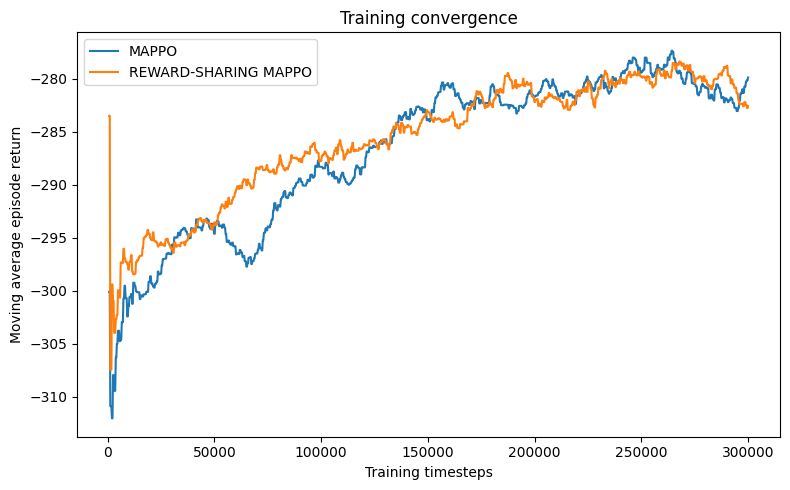

In [10]:
fig, ax = plot_training_histories({
    "MAPPO": mappo_history,
    "Reward-sharing MAPPO": reward_sharing_history,
})
plt.show()

In [11]:
from marl_tsc.evaluate_gifting import gifting_visualisation, print_gifting_summary

print_gifting_summary(reward_sharing_history, traffic_light_ids)


GIFTING SUMMARY — FULL TRAINING RUN

  B1
Giving:
    Mean gift fraction : 0.397
    Mean gift amount   : 0.1826
    Mean raw reward    : -0.4584
    Gift rate          : 0.909
Receiving and Net:    
    Mean received amount : 0.1915
    Mean net transfer    : 0.0089  (net receiver)

  B2
Giving:
    Mean gift fraction : 0.397
    Mean gift amount   : 0.2020
    Mean raw reward    : -0.5072
    Gift rate          : 0.909
Receiving and Net:    
    Mean received amount : 0.1851
    Mean net transfer    : -0.0170  (net donor)

  C1
Giving:
    Mean gift fraction : 0.396
    Mean gift amount   : 0.1816
    Mean raw reward    : -0.4556
    Gift rate          : 0.909
Receiving and Net:    
    Mean received amount : 0.1919
    Mean net transfer    : 0.0103  (net receiver)

  C2
Giving:
    Mean gift fraction : 0.397
    Mean gift amount   : 0.1910
    Mean raw reward    : -0.4787
    Gift rate          : 0.909
Receiving and Net:    
    Mean received amount : 0.1888
    Mean net transfer  

Saved to /content/marl-tsc/outputs/Reward Sharing MAPPO_overview.png


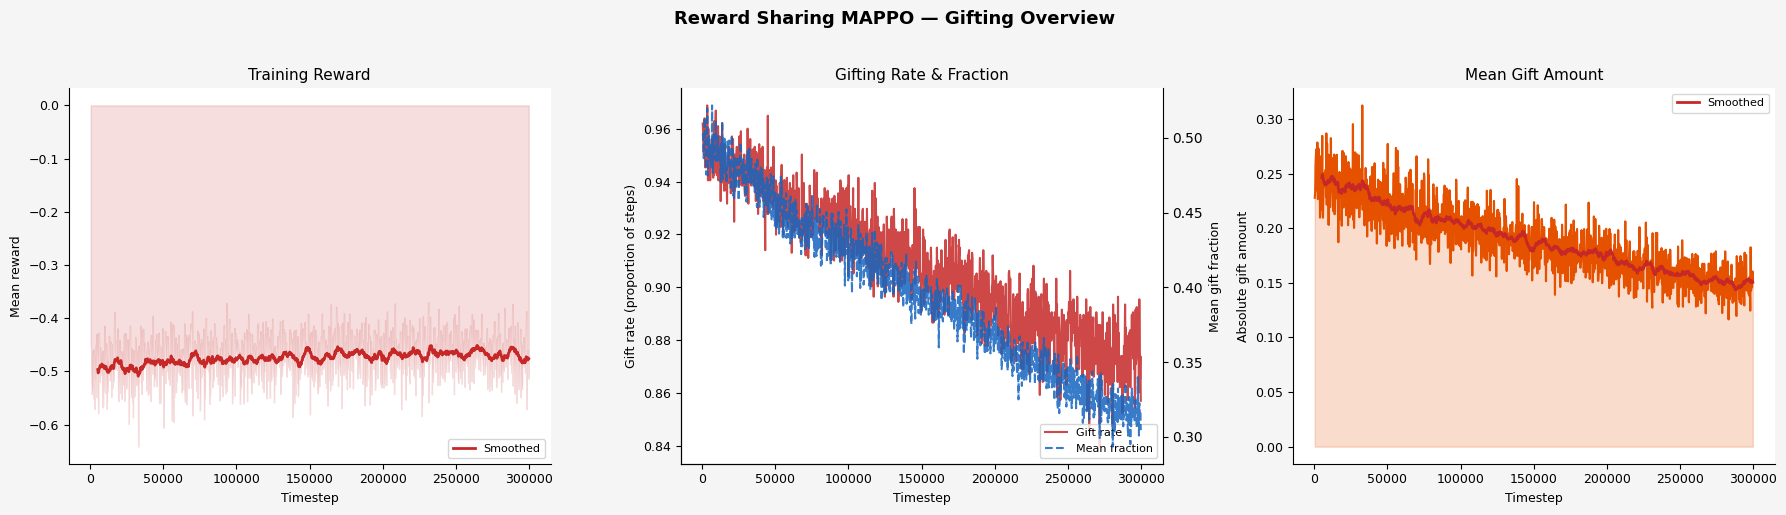

Saved to /content/marl-tsc/outputs/Reward Sharing MAPPO_per_agent.png


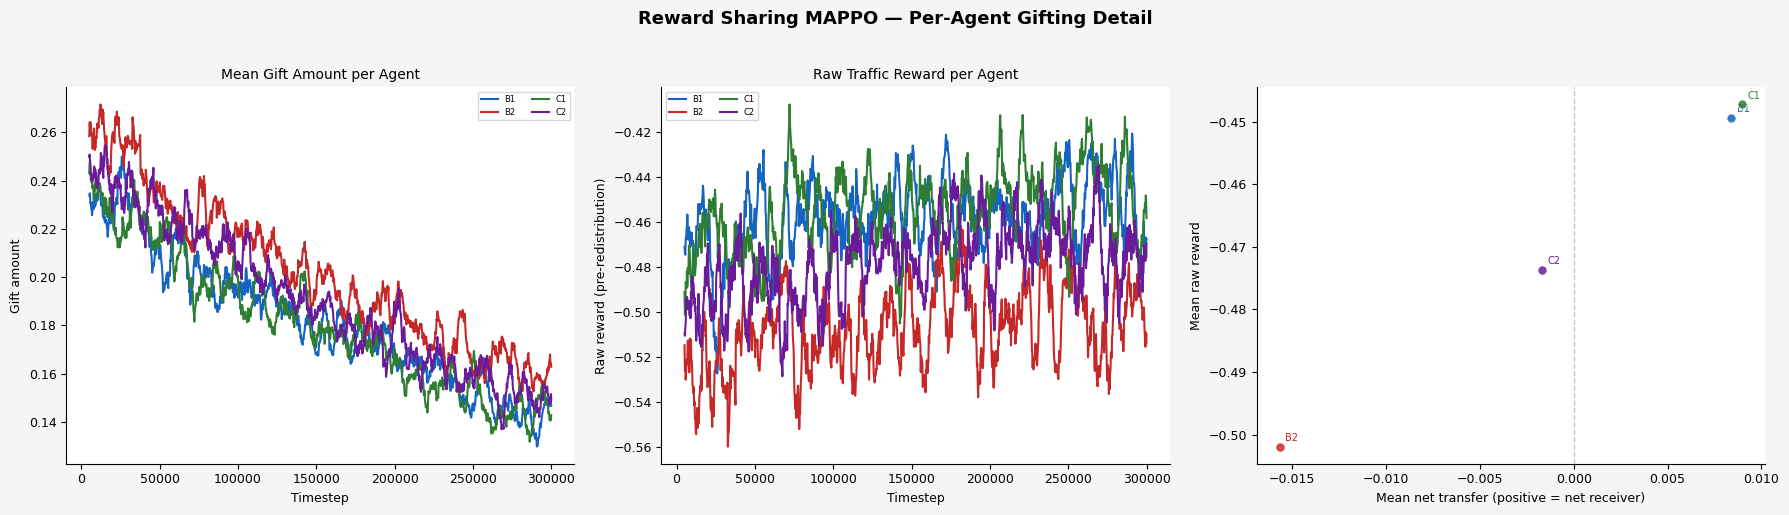

In [13]:
gifting_visualisation(
    history=reward_sharing_history,
    agent_ids=traffic_light_ids,
    algorithm_name="Reward Sharing MAPPO",
    output_dir=str(OUTPUT_DIR),
    smooth_window=20,
    save=True,
    show=True,
)

## 3. Export a SUMO replay

In [ ]:
replay_config = export_policy_replay(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=reward_sharing_model,
    output_dir=OUTPUT_DIR / "replays" / "reward_sharing_mappo",
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)
print(f"Open this file in the SUMO GUI: {replay_config}")

 Retrying in 1 seconds
 Retrying in 1 seconds
Open this file in the SUMO GUI: /content/marl-tsc/outputs/replays/reward_sharing_mappo/replay.sumocfg


## 4. Compare all policies

Every policy uses the same evaluation episodes, seeds, and environment settings.

In [14]:
policies = {
    "Random": random_actions,
    "Fixed-Time": fixed_time_actions,
    "MAPPO": mappo_model,
    "Reward-sharing MAPPO": reward_sharing_model,
}

policy_results = evaluate_policies(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policies=policies,
    episodes=EVALUATION_EPISODES,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)

display(evaluation_results_table(policy_results))

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1131.81
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1239.28
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1264.03
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -988.47
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -987.34
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -982.47
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -456.25
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -431.47
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -431.22
Evaluating Reward-shar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait
0,Random,-1211.7083,0.5046,8.3333,20.8957,244.6667
1,Fixed-Time,-986.0938,0.4106,5.0000,15.3450,89.0000
2,MAPPO,-439.6458,0.1831,4.6667,6.6819,249.6667
3,Reward-sharing MAPPO,-379.9792,0.1582,3.6667,3.5351,128.0000


## 5. Seeded Experiments 4x4

In [27]:
SAVE_TO_DRIVE = True

if IN_COLAB and SAVE_TO_DRIVE:
  from google.colab import drive
  drive.mount('/content/drive')
  OUTPUT_DIR = '/content/drive/MyDrive/Uni-Masters/Group Project/outputs/exp_histories'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
EXP_SWEEP = False

SEED = 46
SEED_RANGE = 5
LEARNING_RATE = 5e-4
if EXP_SWEEP:
    from marl_tsc.exp_functions import save_history, plot_variance
    import torch
    import datetime
    time_stamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    grid= "4x4"

    #select network for seeded evaluation
    network = GridNetwork(4)
    generator = SimulationGenerator(
      output_dir=SIMULATION_DIR,
      network=network,
      trip_begin=0,
      trip_end=TRAFFIC_SPAWN_DURATION,
      trip_period=3,
      seed=SEED,
    )

    paths = generator.generate_all()
    traffic_light_ids = list(paths.traffic_light_ids)

    histories_mappo = []
    histories_rs   = []
    evaluation_histories = []

    ran_single_above = False
    if ran_single_above:
      histories_mappo.append(mappo_history)
      histories_rs.append(reward_sharing_history)
      evaluation_histories.append(policy_results)

    #Run seeded experiment sweeps
    for seed in range(SEED, SEED + SEED_RANGE):
          torch.manual_seed(seed)
          print(f"|Seed: {seed} used for sweep|")

          #Run MAPPO
          mappo_model, mappo_history, mappo_path = train_mappo(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              output_dir=OUTPUT_DIR,
              total_timesteps=TOTAL_TIMESTEPS,
              rollout_steps=256,
              max_steps=EPISODE_STEPS,
              lr = LEARNING_RATE,
              seed=seed,
              env_kwargs=ENV_KWARGS,
              use_peer_reward=False,
          )

          #Run reward sharing
          reward_sharing_model, reward_sharing_history, reward_sharing_path = train_mappo(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              output_dir=OUTPUT_DIR,
              total_timesteps=TOTAL_TIMESTEPS,
              rollout_steps=256,
              max_steps=EPISODE_STEPS,
              lr = LEARNING_RATE,
              seed=seed,
              env_kwargs=ENV_KWARGS,
              use_peer_reward=True,
          )
          #Append and save
          histories_mappo.append(mappo_history)#accumulate in memory
          histories_rs.append(reward_sharing_history)
          save_history(mappo_history, seed, f"mappo_{grid}_@{TOTAL_TIMESTEPS}steps_lr={LEARNING_RATE}_{time_stamp}", OUTPUT_DIR)#save to as backup
          save_history(reward_sharing_history, seed, f"rs__{grid}_@{TOTAL_TIMESTEPS}steps_lr={LEARNING_RATE}_{time_stamp}", OUTPUT_DIR)

          #Display
          fig, ax = plot_training_histories({
          "MAPPO": mappo_history,
          "Reward-sharing MAPPO": reward_sharing_history,
          })
          plt.show()

          #Evaluate
          policies = {
          "Random": random_actions,
          "Fixed-Time": fixed_time_actions,
          "MAPPO": mappo_model,
          "Reward-sharing MAPPO": reward_sharing_model,
          }

          policy_results = evaluate_policies(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              policies=policies,
              episodes=EVALUATION_EPISODES,
              max_steps=EPISODE_STEPS,
              seed=SEED,
              env_kwargs=ENV_KWARGS,
          )
          evaluation_histories.append(policy_results)
          save_history(policy_results, seed, f"evaluation_{grid}_@{TOTAL_TIMESTEPS}steps_lr={LEARNING_RATE}_{time_stamp}", OUTPUT_DIR)

          display(evaluation_results_table(policy_results))
          print_gifting_summary(reward_sharing_history, traffic_light_ids)

    fig, ax = plt.subplots(figsize=(12, 5))
    plot_variance(histories_mappo, "MAPPO",              "#1565C0", ax)
    plot_variance(histories_rs,   "Reward-sharing MAPPO", "#C62828", ax)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Mean training reward")
    ax.legend()
    ax.set_title(f"Training variance across {SEED_RANGE} seeds")
    plt.tight_layout()
    plt.show()

### Results (Loaded from Drive)

In [22]:
LOAD_FROM_DRIVE = True
if LOAD_FROM_DRIVE:
  from google.colab import drive
  drive.mount('/content/drive')
  OUTPUT_DIR = '/content/drive/MyDrive/Uni-Masters/Group Project/outputs/exp_histories'

  import json
  from pathlib import Path

  # Your OUTPUT_DIR should already point to Drive
  output_dir = Path(OUTPUT_DIR)

  # Load all histories by type
  def load_histories(pattern):
      paths = sorted(output_dir.glob(pattern))
      histories = []
      for p in paths:
          with open(p) as f:
              histories.append(json.load(f))
      print(f"Loaded {len(histories)} histories matching '{pattern}'")
      return histories

  # Training histories
  histories_mappo = load_histories("history_mappo_4x4_@300000steps*.json")
  histories_rs    = load_histories("history_rs__4x4_@300000steps*.json")
  evaluation_histories  = load_histories("history_evaluation_4x4_@300000steps*.json")

  print(f"MAPPO seeds: {len(histories_mappo)}")
  print(f"RS seeds:    {len(histories_rs)}")
  print(f"Eval seeds:  {len(evaluation_histories)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 9 histories matching 'history_mappo_4x4_@300000steps*.json'
Loaded 9 histories matching 'history_rs__4x4_@300000steps*.json'
Loaded 9 histories matching 'history_evaluation_4x4_@300000steps*.json'
MAPPO seeds: 9
RS seeds:    9
Eval seeds:  9


#### Training Graphs (Seed by Seed)


Seed 42


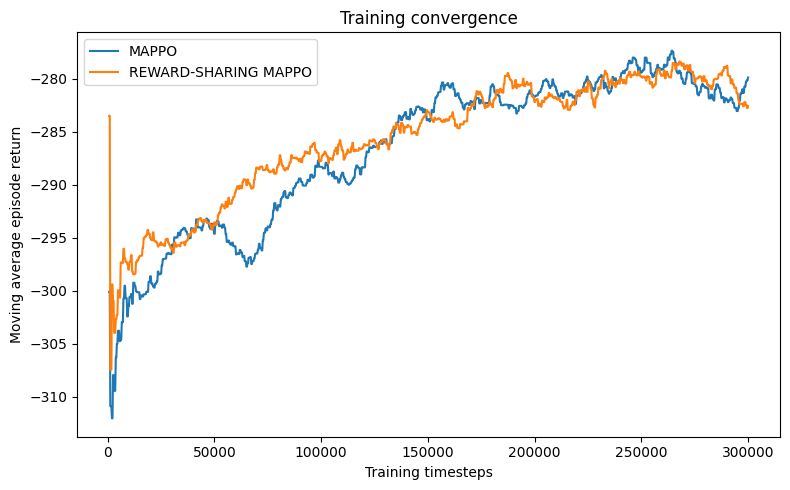


Seed 43


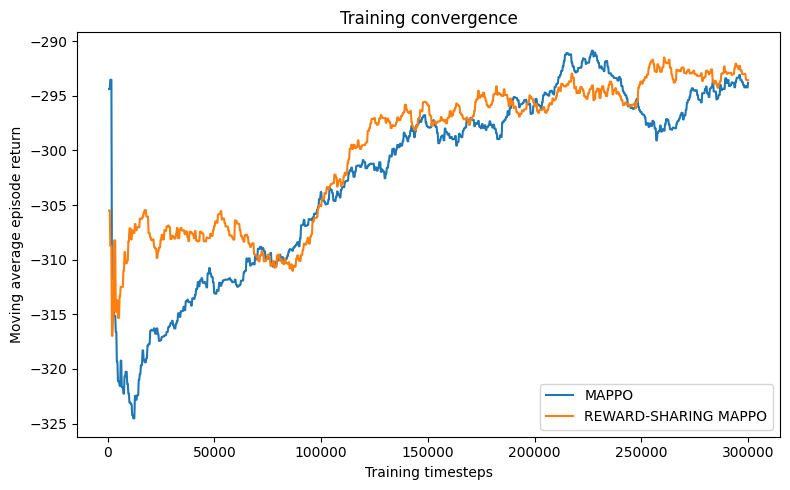


Seed 44


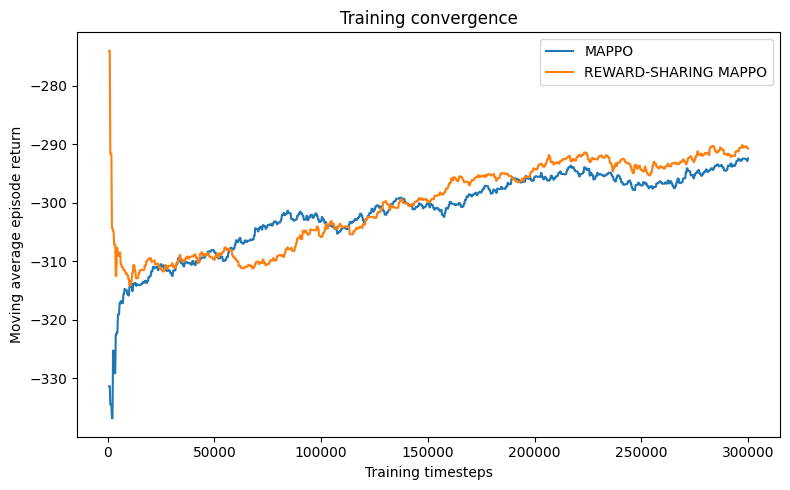


Seed 45


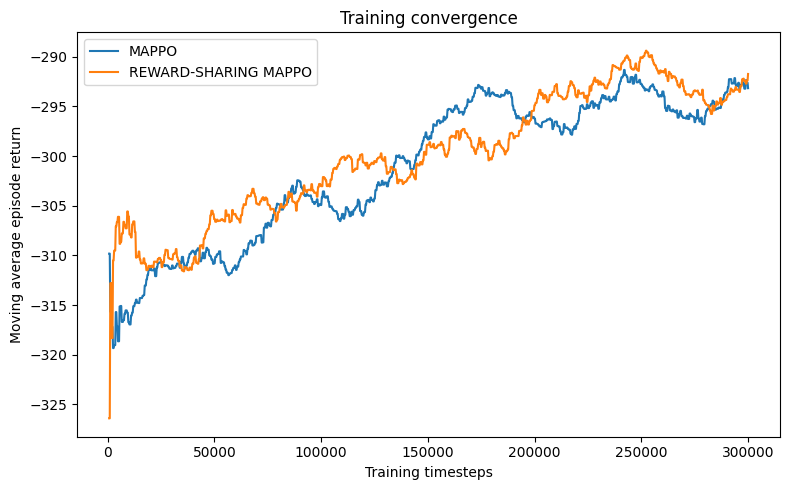


Seed 46


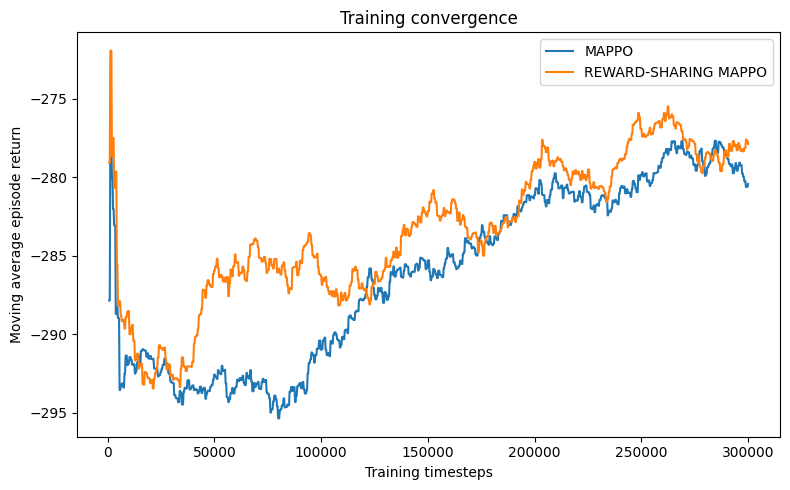


Seed 47


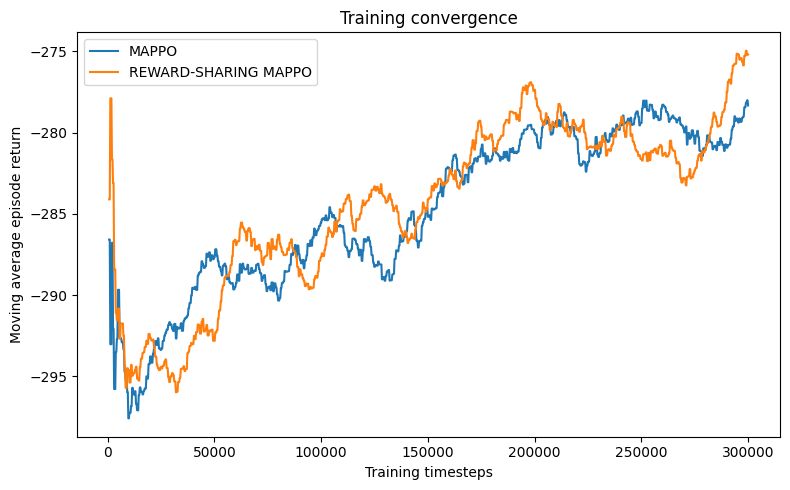


Seed 48


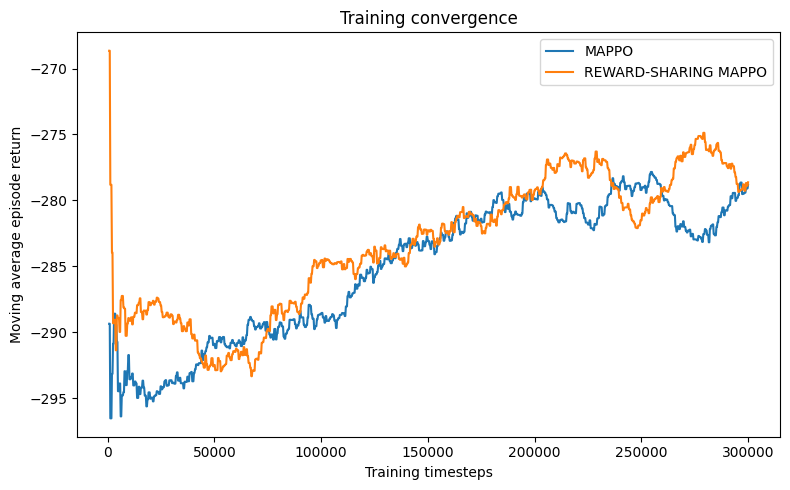


Seed 49


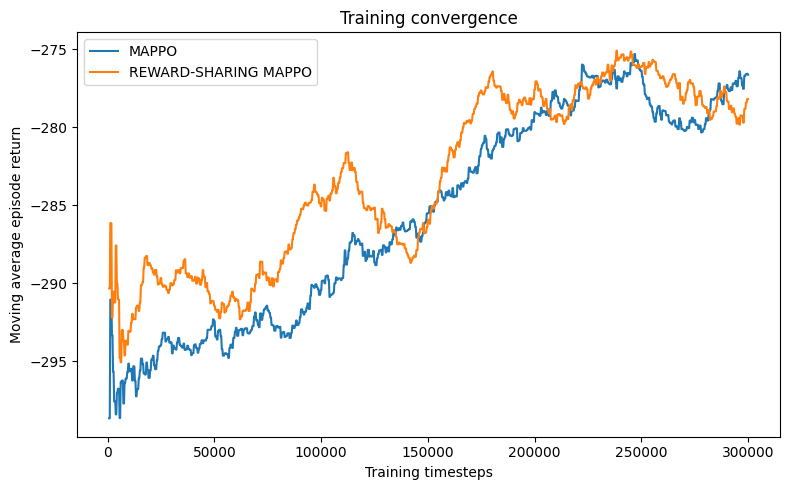


Seed 50


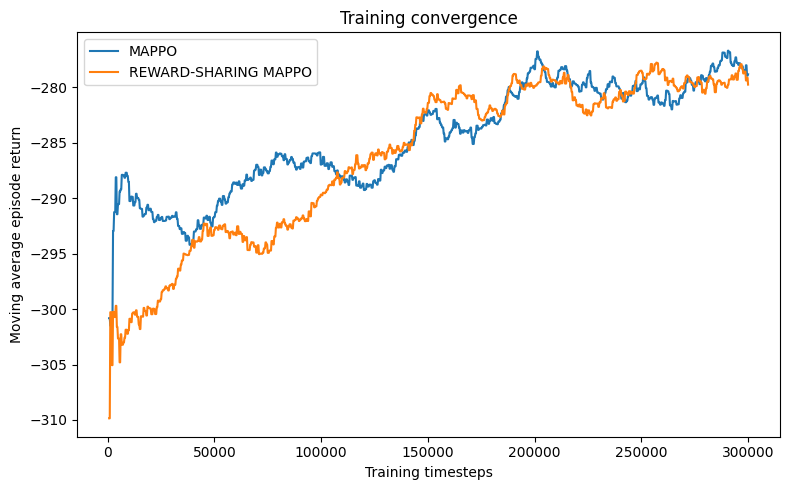

In [67]:
if LOAD_FROM_DRIVE:
    #4x4
    for seed_idx, (mappo_hist, rs_hist) in enumerate(zip(histories_mappo, histories_rs)):
      seed = 42 + seed_idx
      print(f"\nSeed {seed}")

      # Training plots
      fig, ax = plot_training_histories({
          "MAPPO": mappo_hist,
          "Reward-sharing MAPPO": rs_hist,
      })

      plt.show()

#### Evaluation Runs


| Seed  42 | Policy | Mean reward | Mean queue | Mean max queue | Mean wait | Mean max wait |
| :---: | ----- | ----- | ----- | ----- | ----- | ----- |
|  | Random | \-1211.7083 | 0.5046 | 8.3333 | 20.8957 | 244.6667 |
|  | Fixed-Time | \-986.0938 | 0.4106 | 5.0000 | 15.3450 | 89.0000 |
|  | MAPPO | \-439.6458 | 0.1831 | 4.6667 | 6.6819 | 249.6667 |
|  | Reward-sharing MAPPO | \-379.9792 | 0.1582 | 3.6667 | 3.5351 | 128.0000 |

| Seed  43 | Policy | Mean reward | Mean queue | Mean max queue | Mean wait | Mean max wait |
| :---: | ----- | ----- | ----- | ----- | ----- | ----- |
|  | Random | \-1246.8542 | 0.5193 | 9.3333 | 20.0877 | 255.6667 |
|  | Fixed-Time | \-1010.1458 | 0.4206 | 6.3333 | 14.4699 | 88.3333 |
|  | MAPPO | \-550.1979 | 0.2291 | 5.0000 | 9.8022 | 276.6667 |
|  | Reward-sharing MAPPO | \-395.2500 | 0.1646 | 4.6667 | 3.4553 | 124.6667 |

| Seed  44 | Policy | Mean reward | Mean queue | Mean max queue | Mean wait | Mean max wait |
| :---: | ----- | ----- | ----- | ----- | ----- | ----- |
|  | Random | \-1246.8542 | 0.5193 | 9.3333 | 20.0877 | 255.6667 |
|  | Fixed-Time | \-1010.1458 | 0.4206 | 6.3333 | 14.4699 | 88.3333 |
|  | MAPPO | \-621.6979 | 0.2589 | 5.0000 | 12.1368 | 266.0000 |
|  | Reward-sharing MAPPO | \-460.5312 | 0.1918 | 4.6667 | 6.3472 | 188.3333 |

| Seed  45 |  Policy | Mean reward | Mean queue | Mean max queue | Mean wait | Mean max wait |
| :---: | ----- | ----- | ----- | ----- | ----- | ----- |
|  | Random | \-1246.8542 | 0.5193 | 9.333 | 20.0877 | 255.6667 |
|  | Fixed-Time | \-1010.1458 | 0.4206 | 6.333 | 14.4699 | 88.3333 |
|  | MAPPO | \-488.7604 | 0.2036 | 4.333 | 6.6807 | 260.6667 |
|  | Reward-sharing MAPPO | \-642.0938 | 0.2674 | 4.6667 | 11.6863 | 299.0000 |

| Seed  46 |  Policy | Mean reward | Mean queue | Mean max queue | Mean wait | Mean max wait |
| :---: | ----- | ----- | ----- | ----- | ----- | ----- |
|  | Random | \-1183.3125 | 0.4928 | 9 | 20.7035 | 235.6667 |
|  | Fixed-Time | \-974.1562 | 0.4056 | 6 | 14.484 | 88.3333 |
|  | MAPPO | \-384.3958 | 0.1601 | 3.3333 | 3.26 | 115 |
|  | Reward-sharing MAPPO | \-461.3854 | 0.1921 | 4 | 6.3863 | 183.3333 |

| Seed  47 |  Policy | Mean reward | Mean queue | Mean max queue | Mean wait | Mean max wait |
| :---: | ----- | ----- | ----- | ----- | ----- | ----- |
|  | Random | \-1183.3125 | 0.4928 | 9 | 20.7035 | 235.6667 |
|  | Fixed-Time | \-974.1562 | 0.4056 | 6 | 14.484 | 88.3333 |
|  | MAPPO | \-707.2292 | 0.2945 | 4.3333 | 15.2777 | 285 |
|  | Reward-sharing MAPPO | \-473.8333 | 0.1973 | 4 | 6.3599 | 164 |

| Seed  48 |  Policy | Mean reward | Mean queue | Mean max queue | Mean wait | Mean max wait |
| :---: | ----- | ----- | ----- | ----- | ----- | ----- |
|  | Random | \-1183.3125 | 0.4928 | 9 | 20.7035 | 235.6667 |
|  | Fixed-Time | \-974.1562 | 0.4056 | 6 | 14.484 | 88.3333 |
|  | MAPPO | \-388.5417 | 0.1618 | 3.6667 | 3.346 | 123 |
|  | Reward-sharing MAPPO | \-637.3229 | 0.2655 | 4.3333 | 13.5747 | 254.3333 |

| Seed  49 |  Policy | Mean reward | Mean queue | Mean max queue | Mean wait | Mean max wait |
| :---: | ----- | ----- | ----- | ----- | ----- | ----- |
|  | Random | \-1183.3125 | 0.4928 | 9 | 20.7035 | 235.6667 |
|  | Fixed-Time | \-974.1562 | 0.4056 | 6 | 14.484 | 88.3333 |
|  | MAPPO | \-623.2292 | 0.2595 | 4.3333 | 12.7268 | 270.3333 |
|  | Reward-sharing MAPPO | \-454.9583 | 0.1895 | 4 | 6.3847 | 283.3333 |

| Seed  50 |  Policy | Mean reward | Mean queue | Mean max queue | Mean wait | Mean max wait |
| :---: | ----- | ----- | ----- | ----- | ----- | ----- |
|  | Random | \-1183.3125 | 0.4928 | 9 | 20.7035 | 235.6667 |
|  | Fixed-Time | \-974.1562 | 0.4056 | 6 | 14.484 | 88.3333 |
|  | MAPPO | \-463.5625 | 0.193 | 3.6667 | 7.6558 | 265.3333 |
|  | Reward-sharing MAPPO | \-707.2292 | 0.2945 | 4.3333 | 15.2777 | 285 |


### Cross Seed Analysis

#### Variance Graph: Training

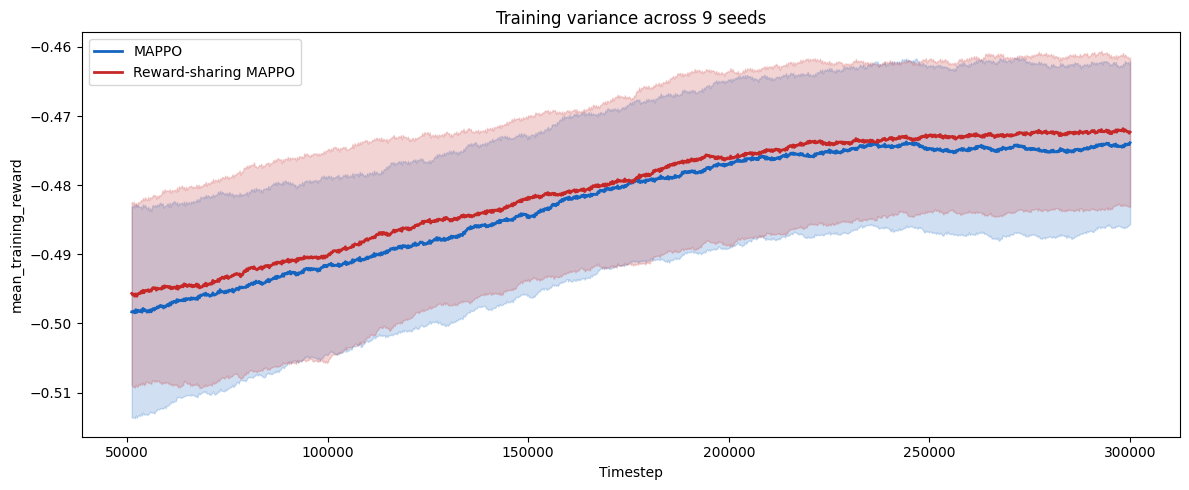

In [42]:
from marl_tsc.exp_functions import plot_variance
smooth = 200
metric = "mean_training_reward"
fig, ax = plt.subplots(figsize=(12, 5))
plot_variance(histories_mappo, "MAPPO",              "#1565C0", ax, metric=metric,smooth=smooth)
plot_variance(histories_rs,   "Reward-sharing MAPPO", "#C62828", ax, metric=metric, smooth=smooth)
ax.set_xlabel("Timestep")
ax.set_ylabel(f"{metric}")
ax.legend()
ax.set_title(f"Training variance across {len(histories_rs)} seeds")
plt.tight_layout()
plt.show()

#### Statistical Significance: Training

In [127]:
EXP_ANALYSIS = True
if EXP_ANALYSIS:
    from scipy import stats
    import numpy as np

    def training_auc(history, metric="mean_training_reward"):
        values = [h[metric] for h in history if metric in h]
        return float(np.trapezoid(values))


    def compare_training_histories(
        histories_a,
        histories_b,
        label_a="MAPPO",
        label_b="Reward-sharing MAPPO",
        metric="mean_training_reward",
        test_type="wilk",
    ):
        print(f"\nMetric: {metric}")
        print("=" * 60)

        # AUC
        aucs_a = [training_auc(h, metric) for h in histories_a]
        aucs_b = [training_auc(h, metric) for h in histories_b]
        print(f"\nAUC (total area under training curve):")
        print(f"  {label_a}: {np.mean(aucs_a):.2f} ± {np.std(aucs_a):.2f}")
        print(f"  {label_b}: {np.mean(aucs_b):.2f} ± {np.std(aucs_b):.2f}")
        if test_type == "wilk":
            stat, p = stats.wilcoxon(aucs_a, aucs_b)
        else:
            stat, p = stats.ttest_rel(aucs_a, aucs_b)

        print(f"  W={stat:.3f}, p={p:.4f}")

        if p < 0.05:
            print(f"  {label_a} and {label_b} show significantly different results")
        else:
            print(f"  {label_a} and {label_b} do not show significantly different results")

    compare_training_histories(
        histories_a=histories_mappo,
        histories_b=histories_rs,
        metric="mean_training_reward",
    )


Metric: mean_training_reward

AUC (total area under training curve):
  MAPPO: -565.92 ± 14.52
  Reward-sharing MAPPO: -563.80 ± 14.32
  W=5.000, p=0.0391
  MAPPO and Reward-sharing MAPPO show significantly different results


#### Overall Performance Metrics: Evaluation

In [86]:
if EXP_ANALYSIS:
  import numpy as np
  import pandas as pd
  metrics = ["mean_total_reward", "mean_local_queue", "mean_waiting_time",
            "mean_max_waiting_time", "mean_total_time_loss"]

  rows = []
  for policy_name in ["Random", "Fixed-Time", "MAPPO", "Reward-sharing MAPPO"]:
      row = {"Policy": policy_name}
      for metric in metrics:
          values = [e[policy_name][metric] for e in evaluation_histories]
          row[f"{metric}_mean"] = np.mean(values)
          row[f"{metric}_std"]  = np.std(values)
      rows.append(row)

  df = pd.DataFrame(rows)
  print('Overall Performance Accross 9 seeds')
  display(df)

Overall Performance Accross 9 seeds


,Policy,mean_total_reward_mean,mean_total_reward_std,mean_local_queue_mean,mean_local_queue_std,mean_waiting_time_mean,mean_waiting_time_std,mean_max_waiting_time_mean,mean_max_waiting_time_std,mean_total_time_loss_mean,mean_total_time_loss_std
0,Random,-1207.648148,29.038173,0.502961,0.012091,20.519632,0.310946,243.333333,9.140873,1676.095435,45.204003
1,Fixed-Time,-987.479167,16.434223,0.411171,0.006866,14.574953,0.272340,88.407407,0.209513,1100.529957,9.264026
2,MAPPO,-518.584491,107.100704,0.215955,0.044610,8.618668,3.943329,234.629630,62.523170,600.973675,173.210955
3,Reward-sharing MAPPO,-512.509259,111.416979,0.213432,0.046400,8.111918,4.065351,212.222222,65.104285,591.174083,175.817838


#### Statistical Significance Tests: Evaluation

In [81]:
if EXP_ANALYSIS:
  # Extract metric across seeds for each policy
  def perform_statisical_tests(metric, evaluation_histories, test_type):
    from scipy import stats
    mappo_grouping = [e["MAPPO"][metric] for e in evaluation_histories]
    rs_grouping   = [e["Reward-sharing MAPPO"][metric] for e in evaluation_histories]

    # Paired t-test — paired because same seed = same traffic conditions
    if test_type == "paired_t":
      _stat, p_value = stats.ttest_rel(mappo_grouping, rs_grouping)
      #print(f"t={_stat:.5f}, p={p_value:.4f}")
    elif test_type == 'wilk':
      _stat, p_value = stats.wilcoxon(mappo_grouping, rs_grouping)
      #print(f"W={_stat:.5f}, p={p_value:.4f}")
    else:
      raise ValueError(f"Unknown test type: {test_type}")

    return _stat, p_value

  metrics = ["mean_total_reward", "mean_local_queue", "mean_waiting_time",
            "mean_max_waiting_time", "mean_total_time_loss"]
  for metric in metrics:
    print(f"Metric) {metric}:")

    w, p = perform_statisical_tests(metric, evaluation_histories, "wilk")
    print(f"    Wilcoxon: t={w:.5f}, p={p:.4f}")
    if p < 0.05:
      print(f"    {metric} shows significantly different results between groups")
    else:
      print(f"    {metric} does not show significantly different results between groups ")
    print('')


Metric) mean_total_reward:
    Wilcoxon: t=22.00000, p=1.0000
    mean_total_reward does not show significantly different results between groups 

Metric) mean_local_queue:
    Wilcoxon: t=22.00000, p=1.0000
    mean_local_queue does not show significantly different results between groups 

Metric) mean_waiting_time:
    Wilcoxon: t=20.00000, p=0.8203
    mean_waiting_time does not show significantly different results between groups 

Metric) mean_max_waiting_time:
    Wilcoxon: t=18.00000, p=0.6523
    mean_max_waiting_time does not show significantly different results between groups 

Metric) mean_total_time_loss:
    Wilcoxon: t=22.00000, p=1.0000
    mean_total_time_loss does not show significantly different results between groups 



In [ ]:
#print( f"Keys for mappo history: {histories_mappo[0][0].keys()}")

In [ ]:
#print(f"Keys for rs-mappo history: {histories_rs[0][0].keys()}")

In [ ]:
#print(f'''Evaluation history Keys:
#{evaluation_histories[0]['MAPPO'].keys()}''')

### Gifting Analysis


Seed 42


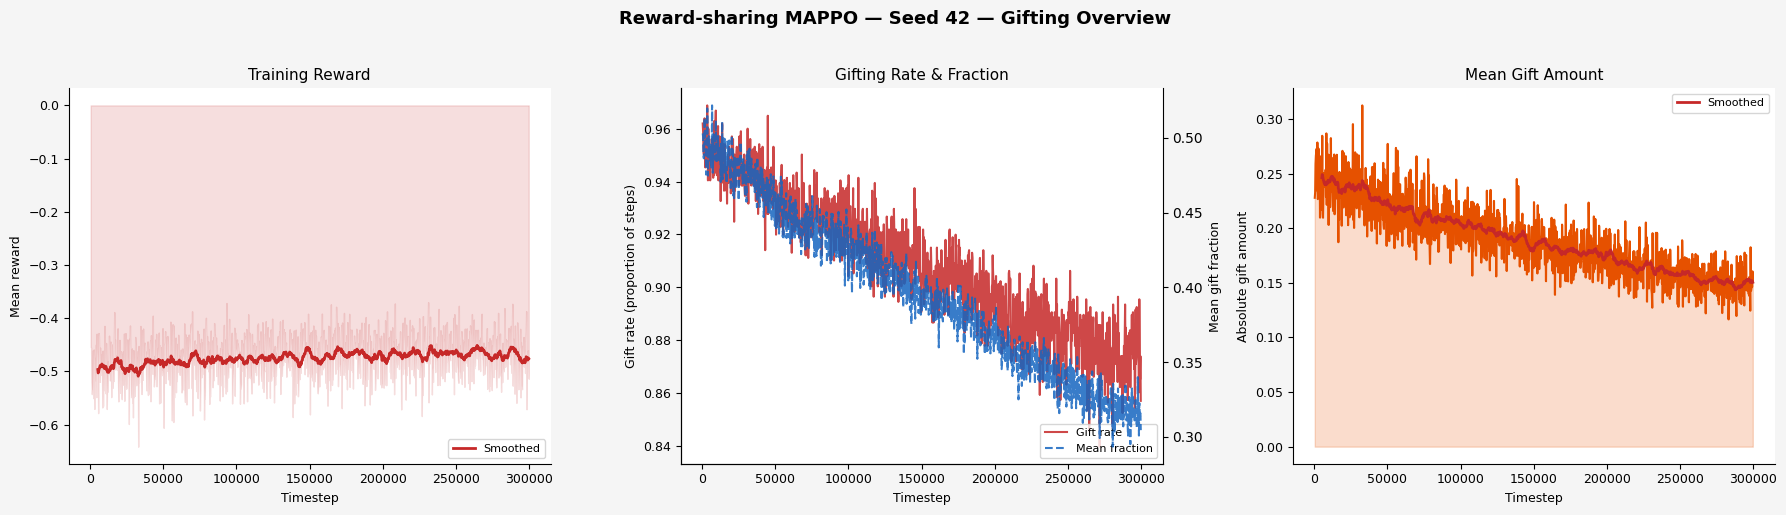

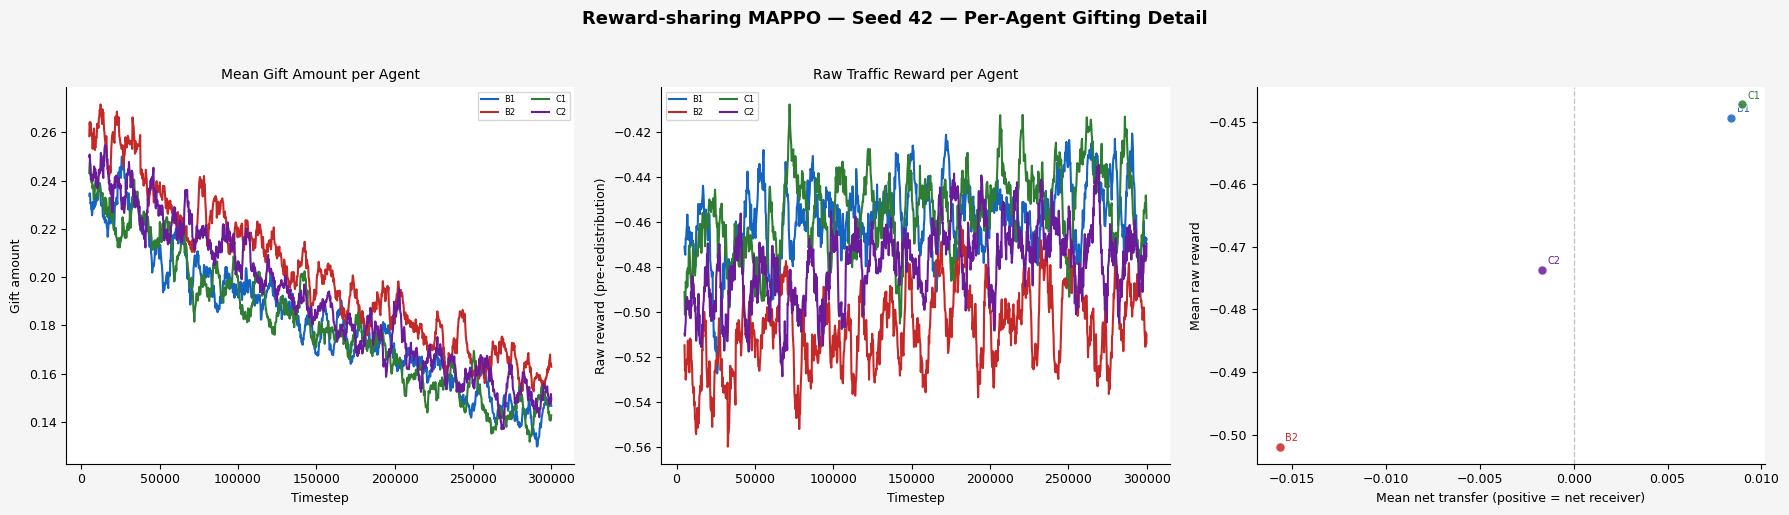


GIFTING SUMMARY — FULL TRAINING RUN

  B1
Giving:
    Mean gift fraction : 0.397
    Mean gift amount   : 0.1826
    Mean raw reward    : -0.4584
    Gift rate          : 0.909
Receiving and Net:    
    Mean received amount : 0.1915
    Mean net transfer    : 0.0089  (net receiver)

  B2
Giving:
    Mean gift fraction : 0.397
    Mean gift amount   : 0.2020
    Mean raw reward    : -0.5072
    Gift rate          : 0.909
Receiving and Net:    
    Mean received amount : 0.1851
    Mean net transfer    : -0.0170  (net donor)

  C1
Giving:
    Mean gift fraction : 0.396
    Mean gift amount   : 0.1816
    Mean raw reward    : -0.4556
    Gift rate          : 0.909
Receiving and Net:    
    Mean received amount : 0.1919
    Mean net transfer    : 0.0103  (net receiver)

  C2
Giving:
    Mean gift fraction : 0.397
    Mean gift amount   : 0.1910
    Mean raw reward    : -0.4787
    Gift rate          : 0.909
Receiving and Net:    
    Mean received amount : 0.1888
    Mean net transfer  

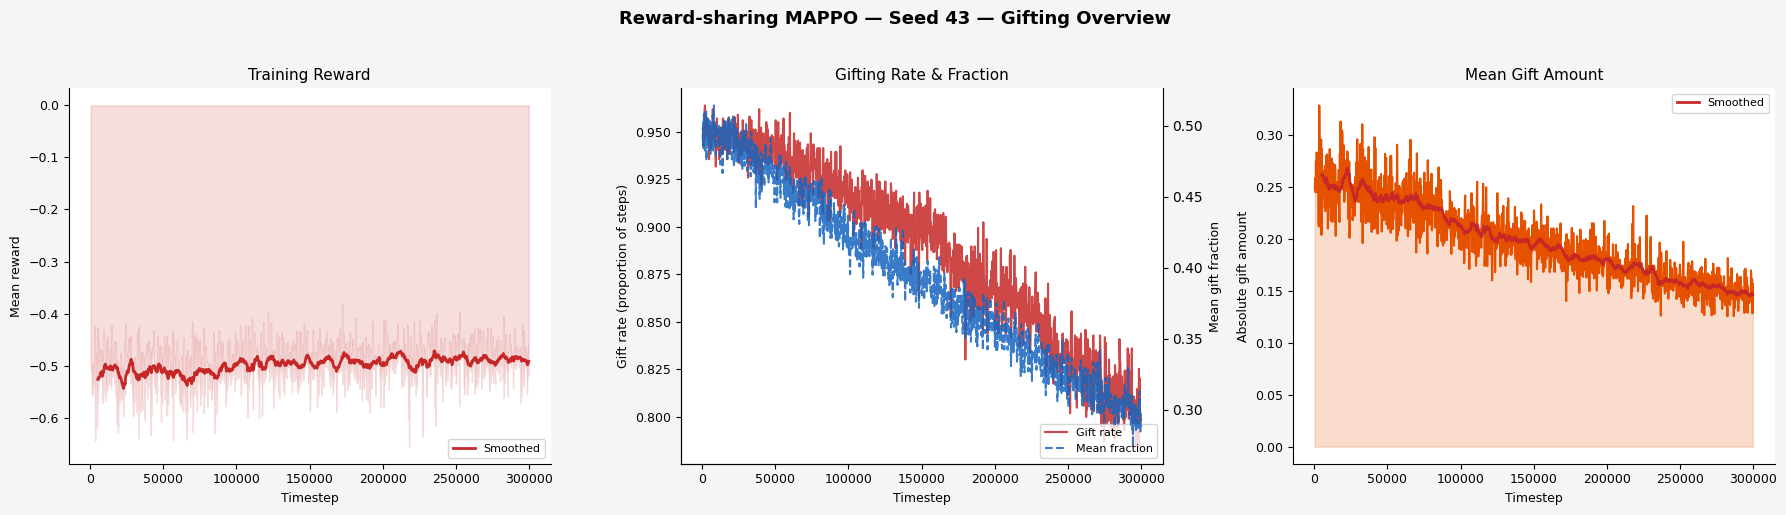

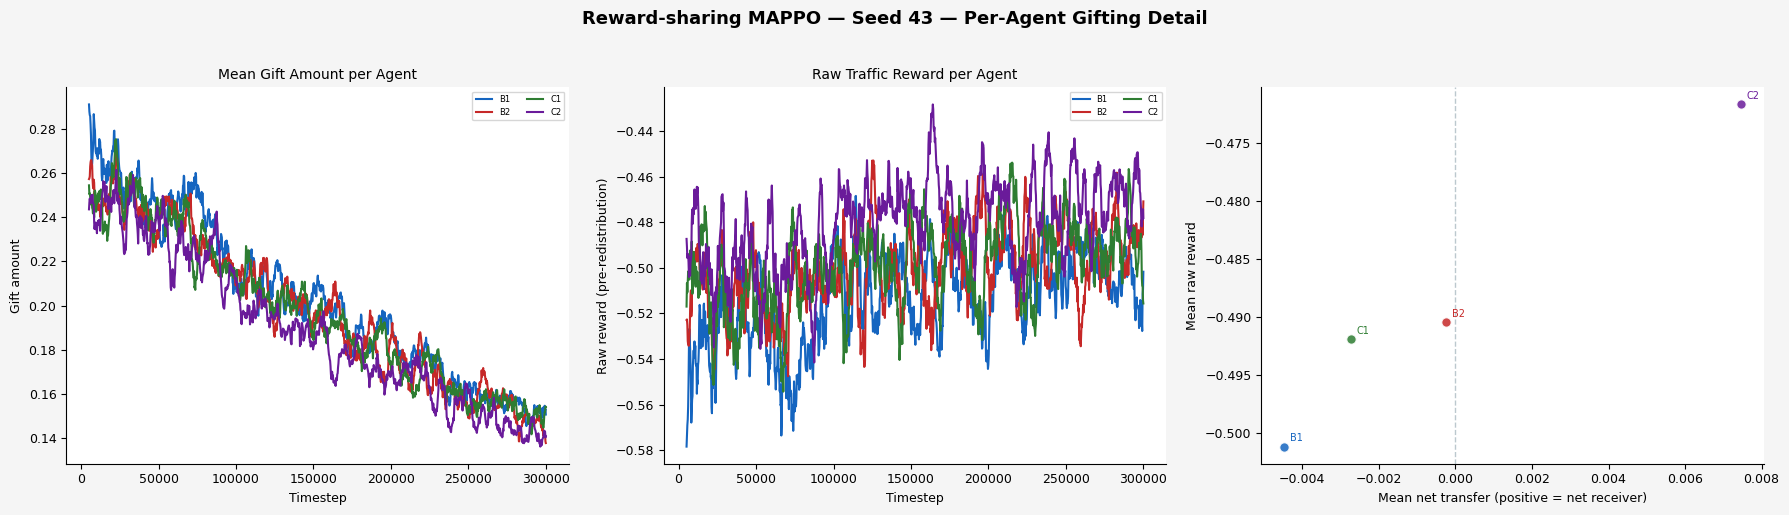


GIFTING SUMMARY — FULL TRAINING RUN

  B1
Giving:
    Mean gift fraction : 0.393
    Mean gift amount   : 0.2037
    Mean raw reward    : -0.5142
    Gift rate          : 0.888
Receiving and Net:    
    Mean received amount : 0.1951
    Mean net transfer    : -0.0086  (net donor)

  B2
Giving:
    Mean gift fraction : 0.393
    Mean gift amount   : 0.1978
    Mean raw reward    : -0.5002
    Gift rate          : 0.888
Receiving and Net:    
    Mean received amount : 0.1971
    Mean net transfer    : -0.0006  (net donor)

  C1
Giving:
    Mean gift fraction : 0.393
    Mean gift amount   : 0.1978
    Mean raw reward    : -0.4997
    Gift rate          : 0.889
Receiving and Net:    
    Mean received amount : 0.1971
    Mean net transfer    : -0.0006  (net donor)

  C2
Giving:
    Mean gift fraction : 0.393
    Mean gift amount   : 0.1899
    Mean raw reward    : -0.4805
    Gift rate          : 0.888
Receiving and Net:    
    Mean received amount : 0.1998
    Mean net transfer    : 

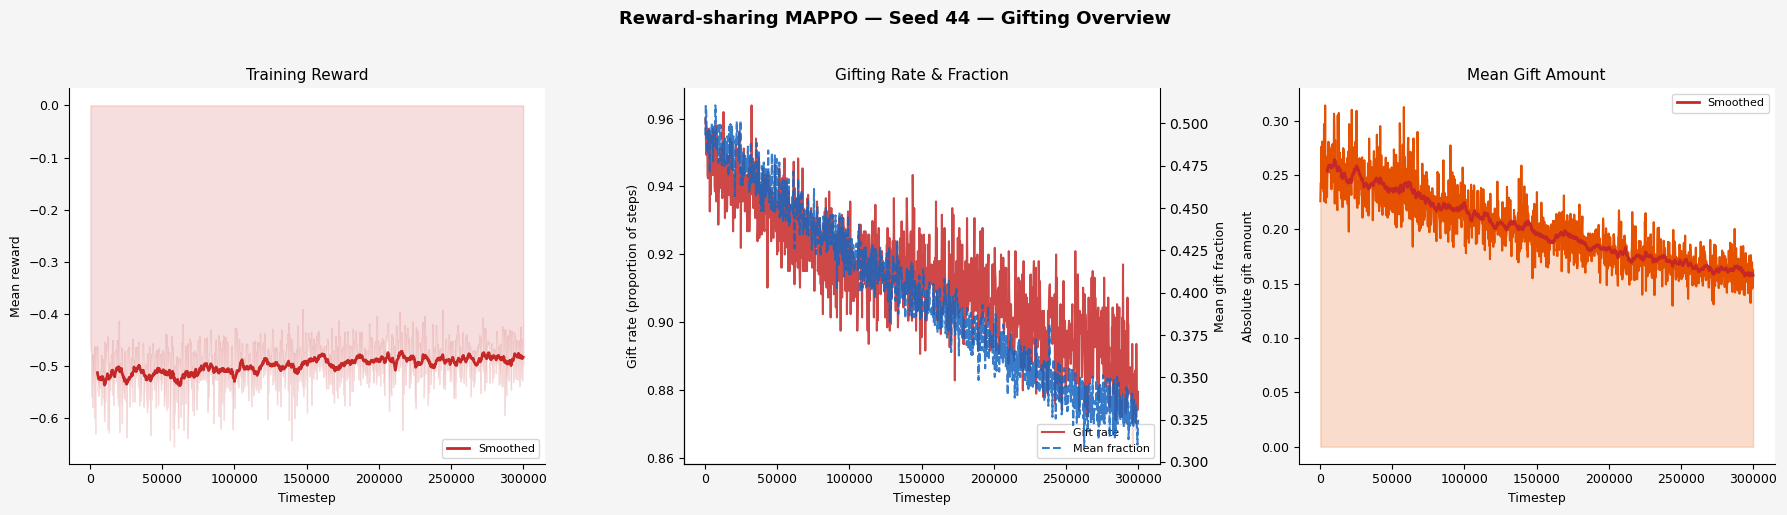

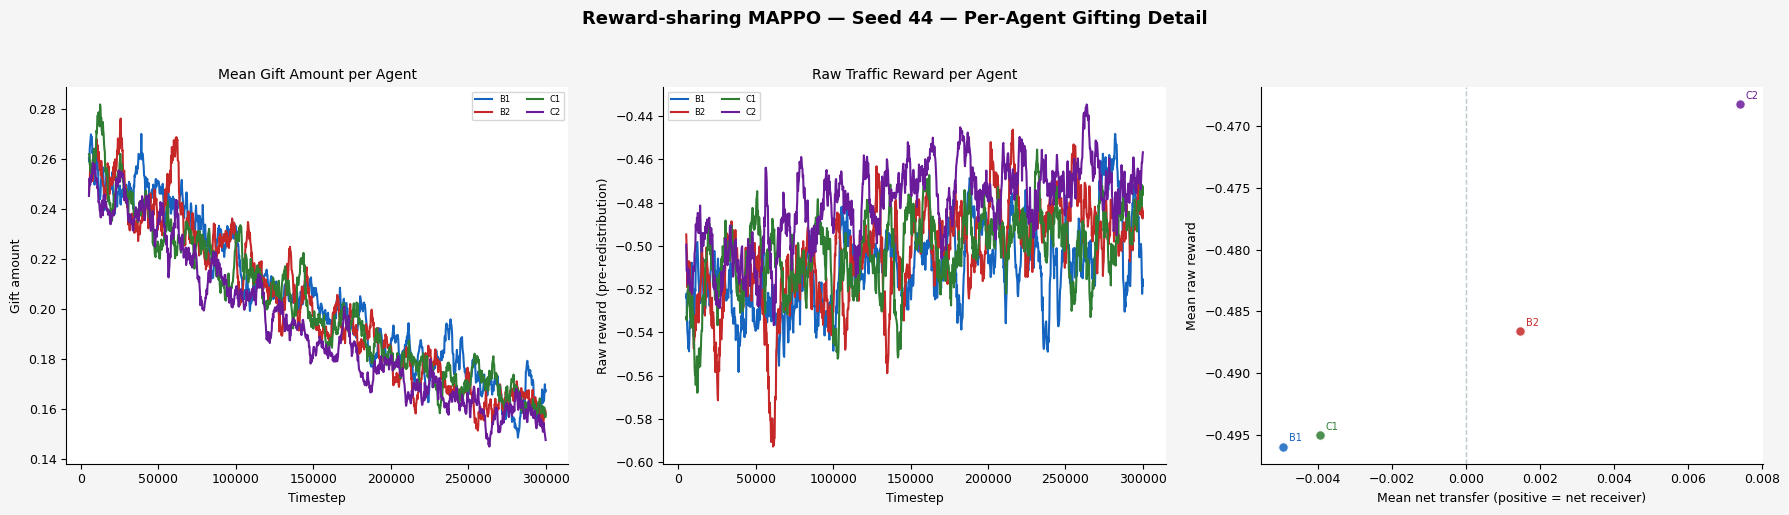


GIFTING SUMMARY — FULL TRAINING RUN

  B1
Giving:
    Mean gift fraction : 0.400
    Mean gift amount   : 0.2053
    Mean raw reward    : -0.5097
    Gift rate          : 0.913
Receiving and Net:    
    Mean received amount : 0.1992
    Mean net transfer    : -0.0061  (net donor)

  B2
Giving:
    Mean gift fraction : 0.399
    Mean gift amount   : 0.2022
    Mean raw reward    : -0.5032
    Gift rate          : 0.913
Receiving and Net:    
    Mean received amount : 0.2002
    Mean net transfer    : -0.0020  (net donor)

  C1
Giving:
    Mean gift fraction : 0.399
    Mean gift amount   : 0.2017
    Mean raw reward    : -0.5026
    Gift rate          : 0.914
Receiving and Net:    
    Mean received amount : 0.2004
    Mean net transfer    : -0.0013  (net donor)

  C2
Giving:
    Mean gift fraction : 0.401
    Mean gift amount   : 0.1937
    Mean raw reward    : -0.4808
    Gift rate          : 0.914
Receiving and Net:    
    Mean received amount : 0.2031
    Mean net transfer    : 

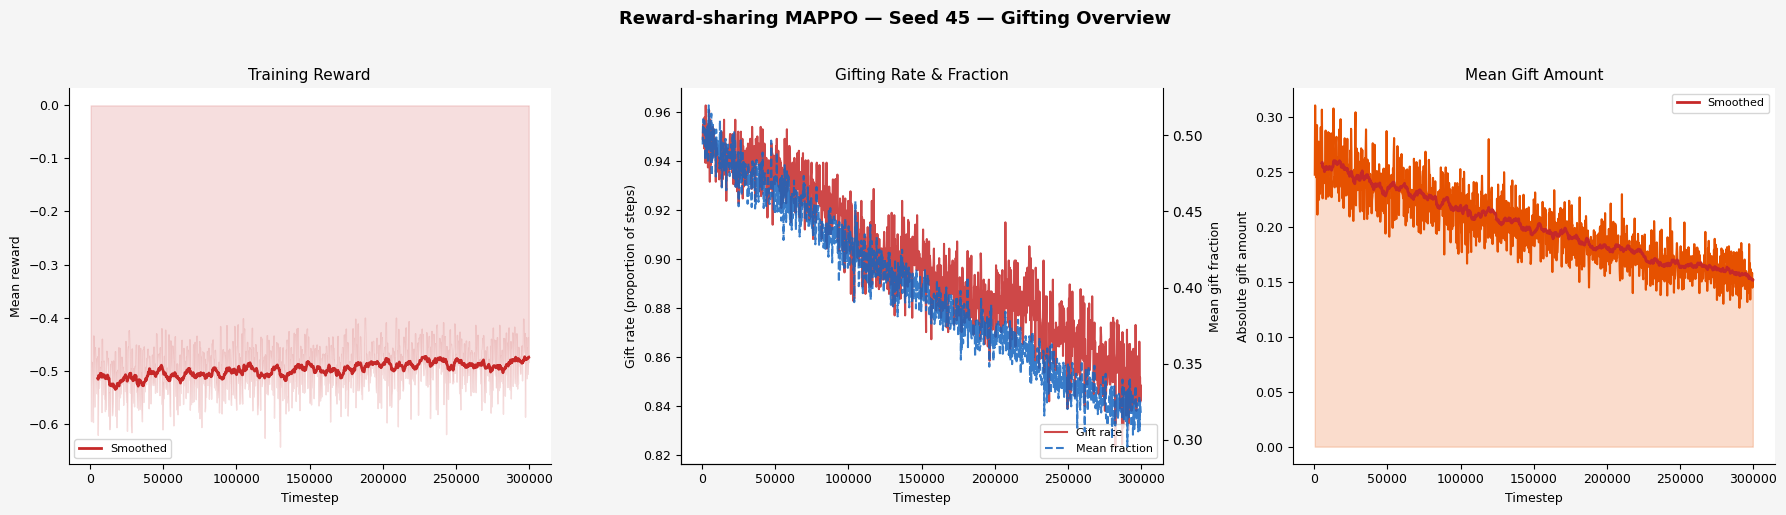

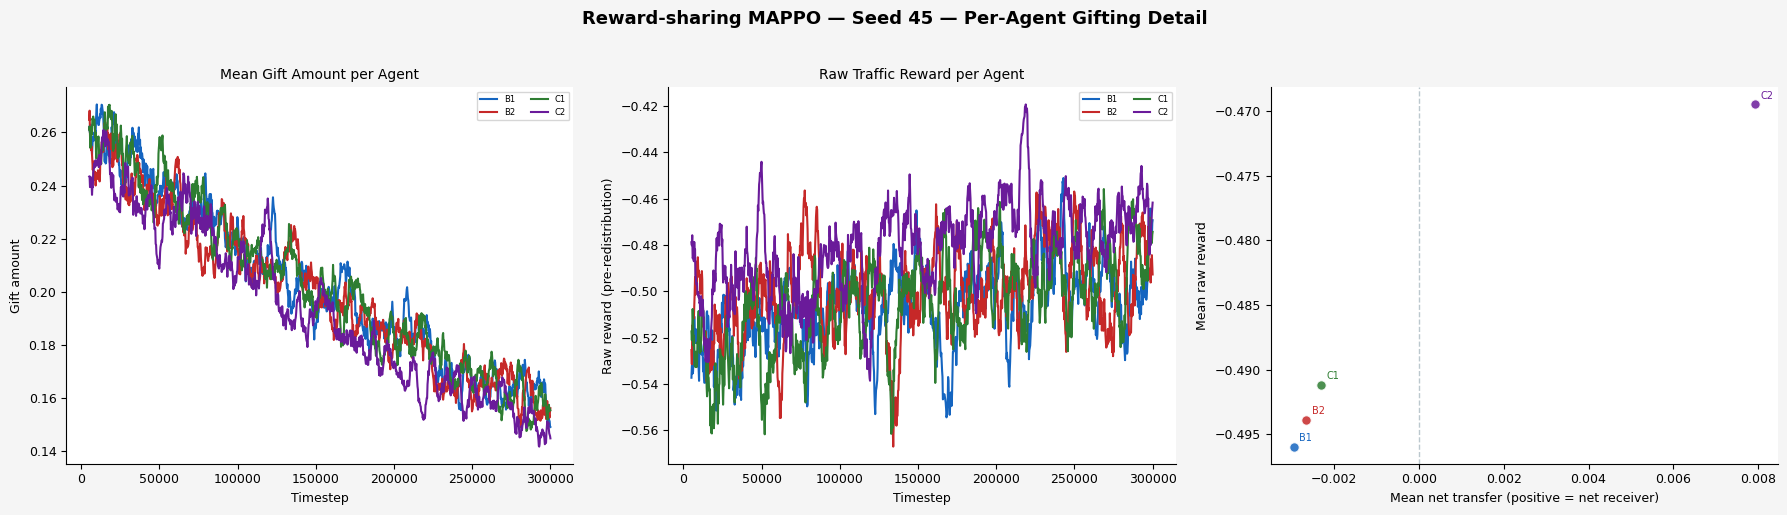


GIFTING SUMMARY — FULL TRAINING RUN

  B1
Giving:
    Mean gift fraction : 0.399
    Mean gift amount   : 0.2033
    Mean raw reward    : -0.5062
    Gift rate          : 0.899
Receiving and Net:    
    Mean received amount : 0.1993
    Mean net transfer    : -0.0040  (net donor)

  B2
Giving:
    Mean gift fraction : 0.399
    Mean gift amount   : 0.2007
    Mean raw reward    : -0.5002
    Gift rate          : 0.899
Receiving and Net:    
    Mean received amount : 0.2001
    Mean net transfer    : -0.0006  (net donor)

  C1
Giving:
    Mean gift fraction : 0.400
    Mean gift amount   : 0.2031
    Mean raw reward    : -0.5052
    Gift rate          : 0.899
Receiving and Net:    
    Mean received amount : 0.1994
    Mean net transfer    : -0.0037  (net donor)

  C2
Giving:
    Mean gift fraction : 0.400
    Mean gift amount   : 0.1940
    Mean raw reward    : -0.4813
    Gift rate          : 0.899
Receiving and Net:    
    Mean received amount : 0.2024
    Mean net transfer    : 

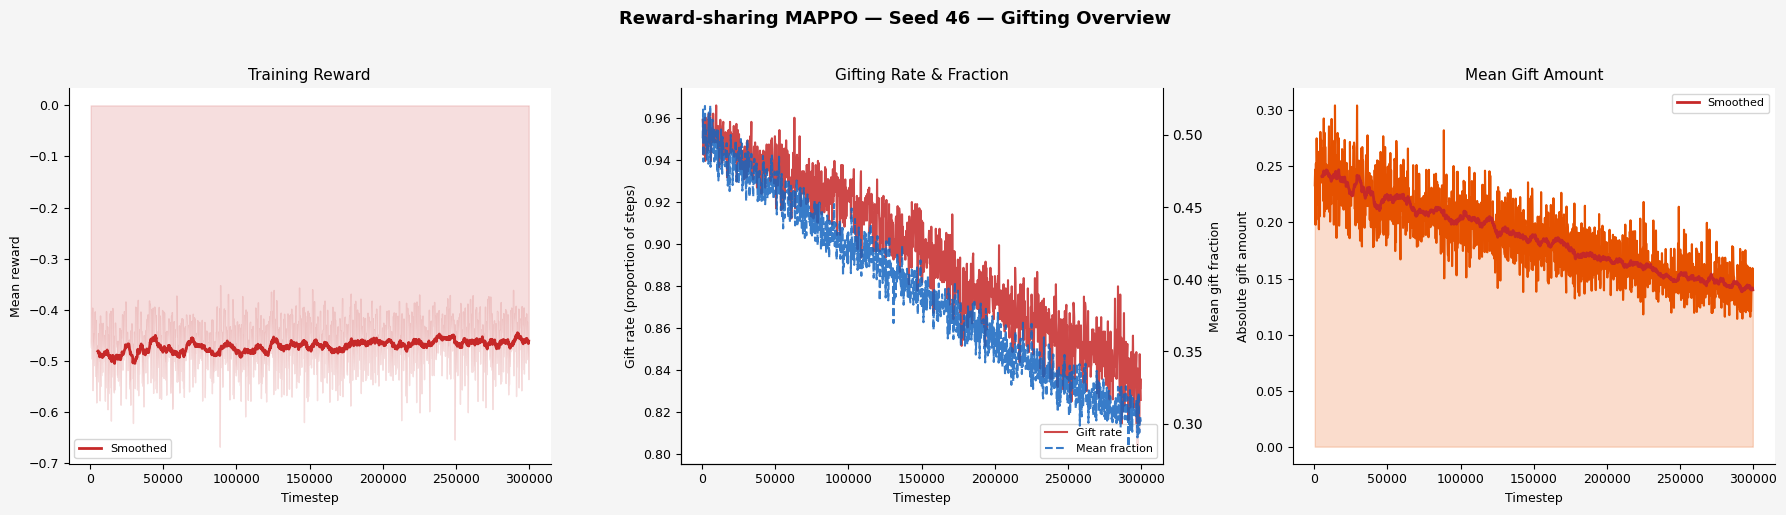

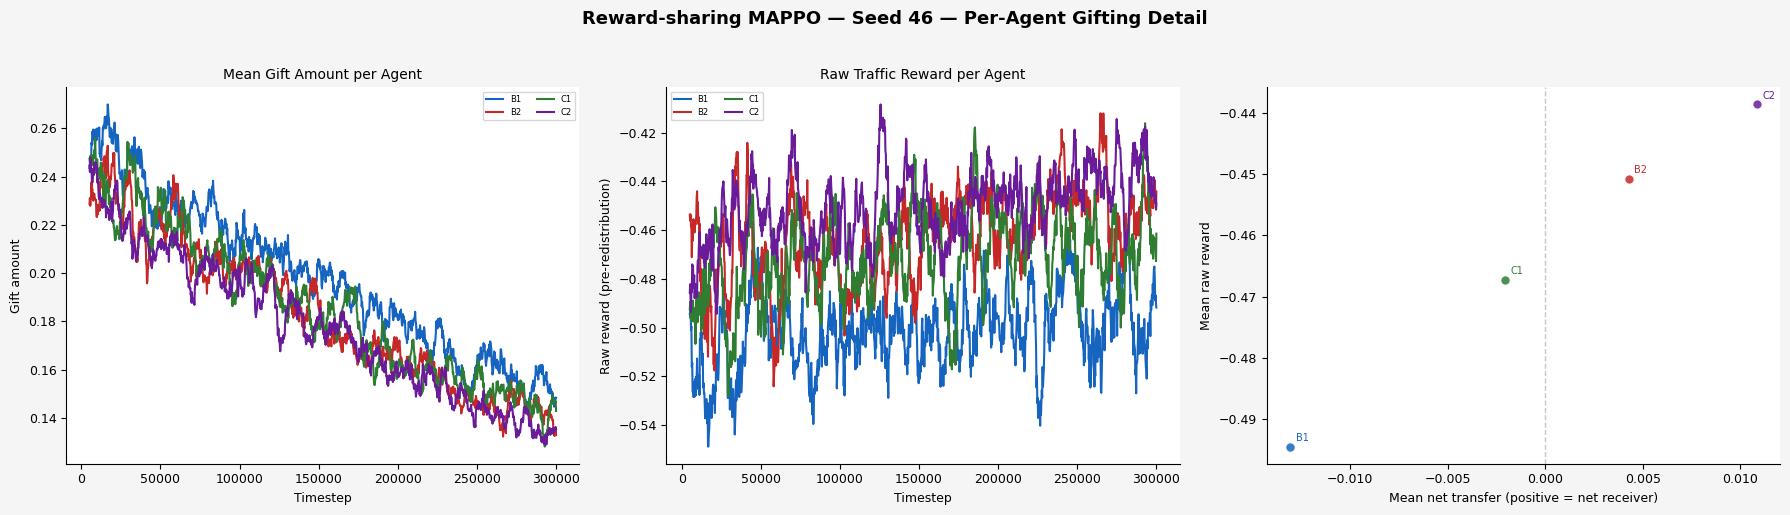


GIFTING SUMMARY — FULL TRAINING RUN

  B1
Giving:
    Mean gift fraction : 0.393
    Mean gift amount   : 0.1980
    Mean raw reward    : -0.5016
    Gift rate          : 0.895
Receiving and Net:    
    Mean received amount : 0.1822
    Mean net transfer    : -0.0158  (net donor)

  B2
Giving:
    Mean gift fraction : 0.393
    Mean gift amount   : 0.1829
    Mean raw reward    : -0.4629
    Gift rate          : 0.895
Receiving and Net:    
    Mean received amount : 0.1873
    Mean net transfer    : 0.0044  (net receiver)

  C1
Giving:
    Mean gift fraction : 0.393
    Mean gift amount   : 0.1857
    Mean raw reward    : -0.4709
    Gift rate          : 0.896
Receiving and Net:    
    Mean received amount : 0.1864
    Mean net transfer    : 0.0007  (net receiver)

  C2
Giving:
    Mean gift fraction : 0.393
    Mean gift amount   : 0.1782
    Mean raw reward    : -0.4506
    Gift rate          : 0.896
Receiving and Net:    
    Mean received amount : 0.1888
    Mean net transfer  

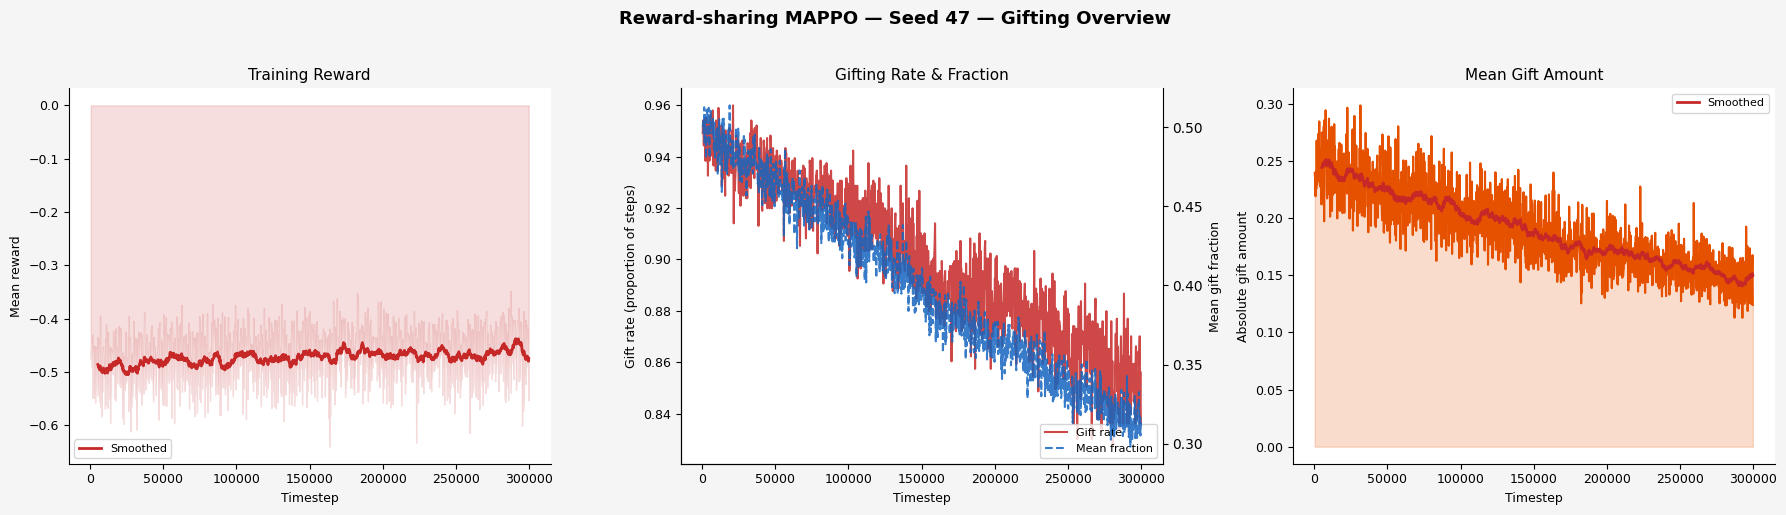

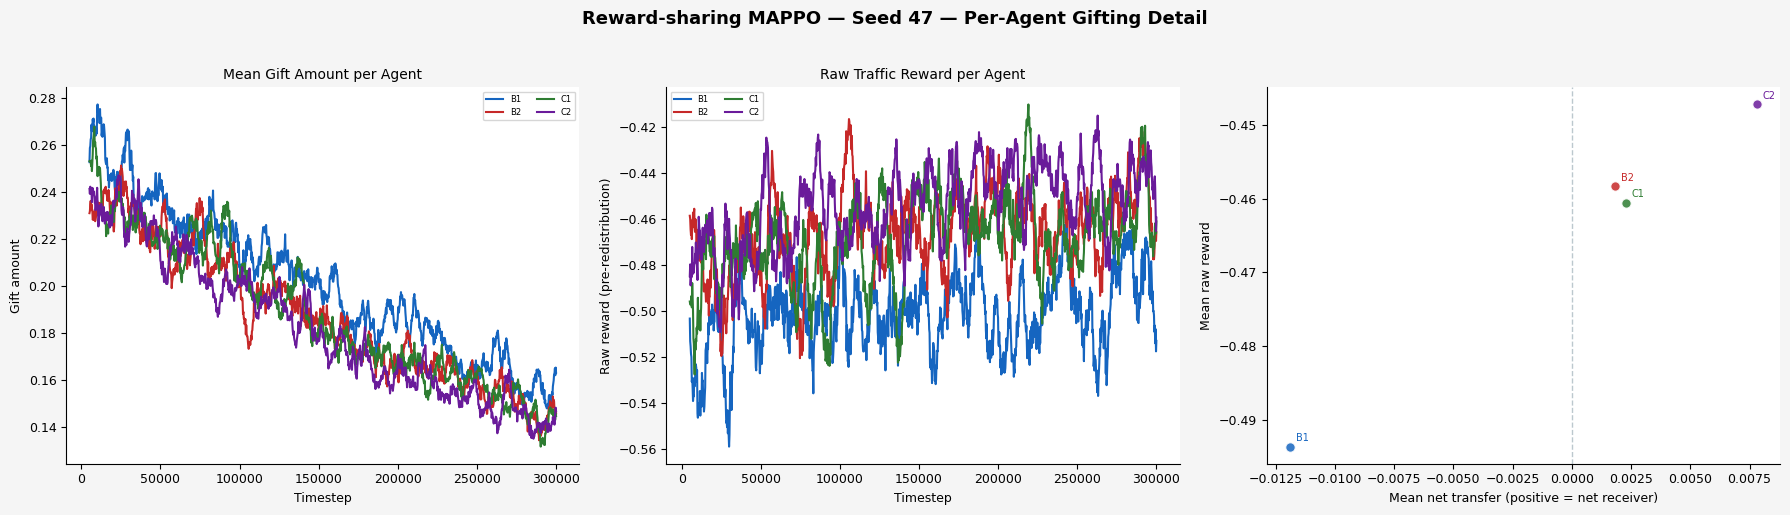


GIFTING SUMMARY — FULL TRAINING RUN

  B1
Giving:
    Mean gift fraction : 0.400
    Mean gift amount   : 0.2013
    Mean raw reward    : -0.5014
    Gift rate          : 0.899
Receiving and Net:    
    Mean received amount : 0.1862
    Mean net transfer    : -0.0151  (net donor)

  B2
Giving:
    Mean gift fraction : 0.400
    Mean gift amount   : 0.1873
    Mean raw reward    : -0.4661
    Gift rate          : 0.901
Receiving and Net:    
    Mean received amount : 0.1908
    Mean net transfer    : 0.0035  (net receiver)

  C1
Giving:
    Mean gift fraction : 0.399
    Mean gift amount   : 0.1884
    Mean raw reward    : -0.4685
    Gift rate          : 0.900
Receiving and Net:    
    Mean received amount : 0.1905
    Mean net transfer    : 0.0021  (net receiver)

  C2
Giving:
    Mean gift fraction : 0.399
    Mean gift amount   : 0.1828
    Mean raw reward    : -0.4548
    Gift rate          : 0.899
Receiving and Net:    
    Mean received amount : 0.1923
    Mean net transfer  

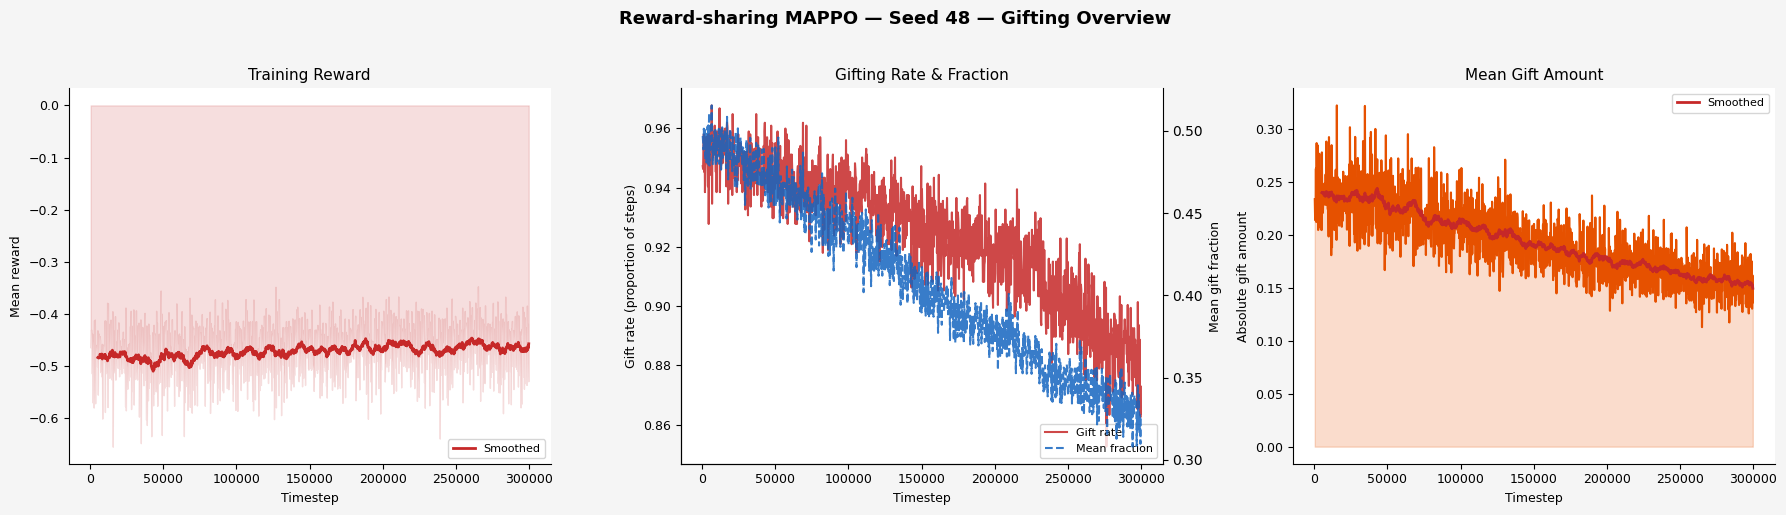

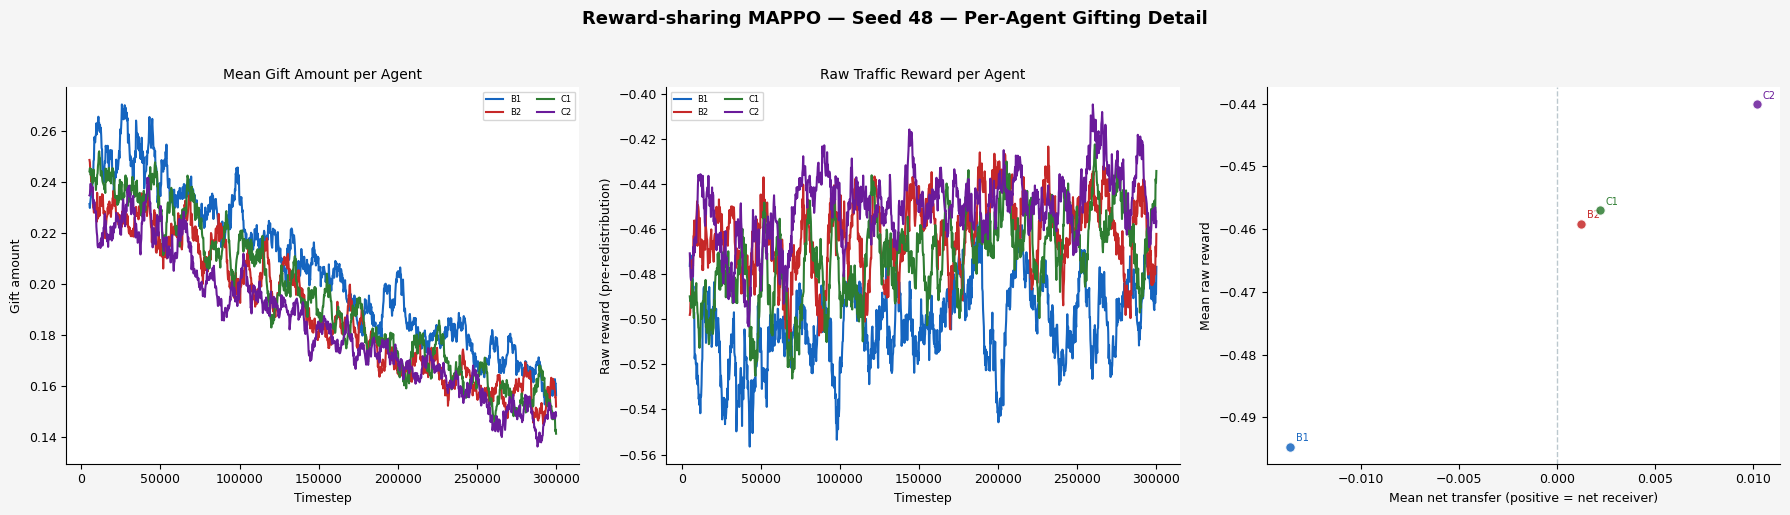


GIFTING SUMMARY — FULL TRAINING RUN

  B1
Giving:
    Mean gift fraction : 0.409
    Mean gift amount   : 0.2061
    Mean raw reward    : -0.5017
    Gift rate          : 0.924
Receiving and Net:    
    Mean received amount : 0.1897
    Mean net transfer    : -0.0165  (net donor)

  B2
Giving:
    Mean gift fraction : 0.409
    Mean gift amount   : 0.1901
    Mean raw reward    : -0.4626
    Gift rate          : 0.925
Receiving and Net:    
    Mean received amount : 0.1950
    Mean net transfer    : 0.0049  (net receiver)

  C1
Giving:
    Mean gift fraction : 0.409
    Mean gift amount   : 0.1942
    Mean raw reward    : -0.4721
    Gift rate          : 0.924
Receiving and Net:    
    Mean received amount : 0.1936
    Mean net transfer    : -0.0006  (net donor)

  C2
Giving:
    Mean gift fraction : 0.408
    Mean gift amount   : 0.1846
    Mean raw reward    : -0.4499
    Gift rate          : 0.924
Receiving and Net:    
    Mean received amount : 0.1968
    Mean net transfer    

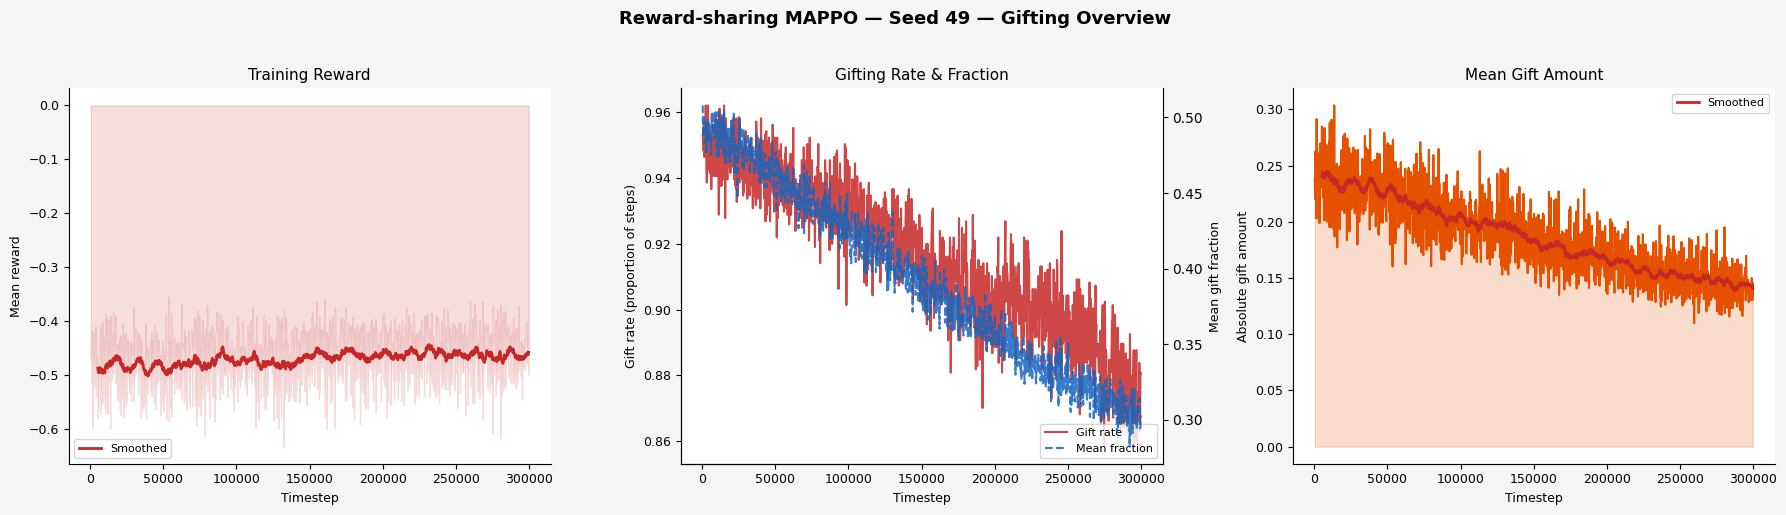

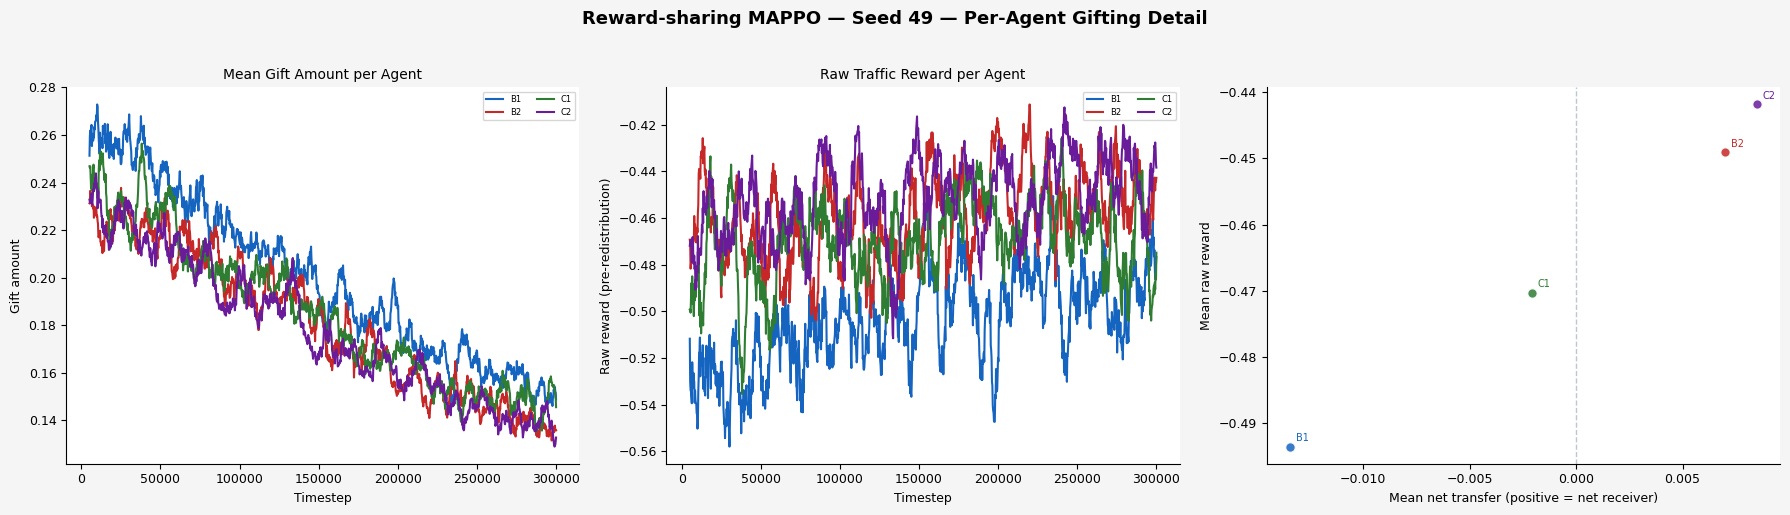


GIFTING SUMMARY — FULL TRAINING RUN

  B1
Giving:
    Mean gift fraction : 0.393
    Mean gift amount   : 0.1999
    Mean raw reward    : -0.5038
    Gift rate          : 0.916
Receiving and Net:    
    Mean received amount : 0.1816
    Mean net transfer    : -0.0183  (net donor)

  B2
Giving:
    Mean gift fraction : 0.392
    Mean gift amount   : 0.1812
    Mean raw reward    : -0.4591
    Gift rate          : 0.916
Receiving and Net:    
    Mean received amount : 0.1879
    Mean net transfer    : 0.0067  (net receiver)

  C1
Giving:
    Mean gift fraction : 0.392
    Mean gift amount   : 0.1852
    Mean raw reward    : -0.4694
    Gift rate          : 0.915
Receiving and Net:    
    Mean received amount : 0.1865
    Mean net transfer    : 0.0013  (net receiver)

  C2
Giving:
    Mean gift fraction : 0.393
    Mean gift amount   : 0.1785
    Mean raw reward    : -0.4517
    Gift rate          : 0.916
Receiving and Net:    
    Mean received amount : 0.1888
    Mean net transfer  

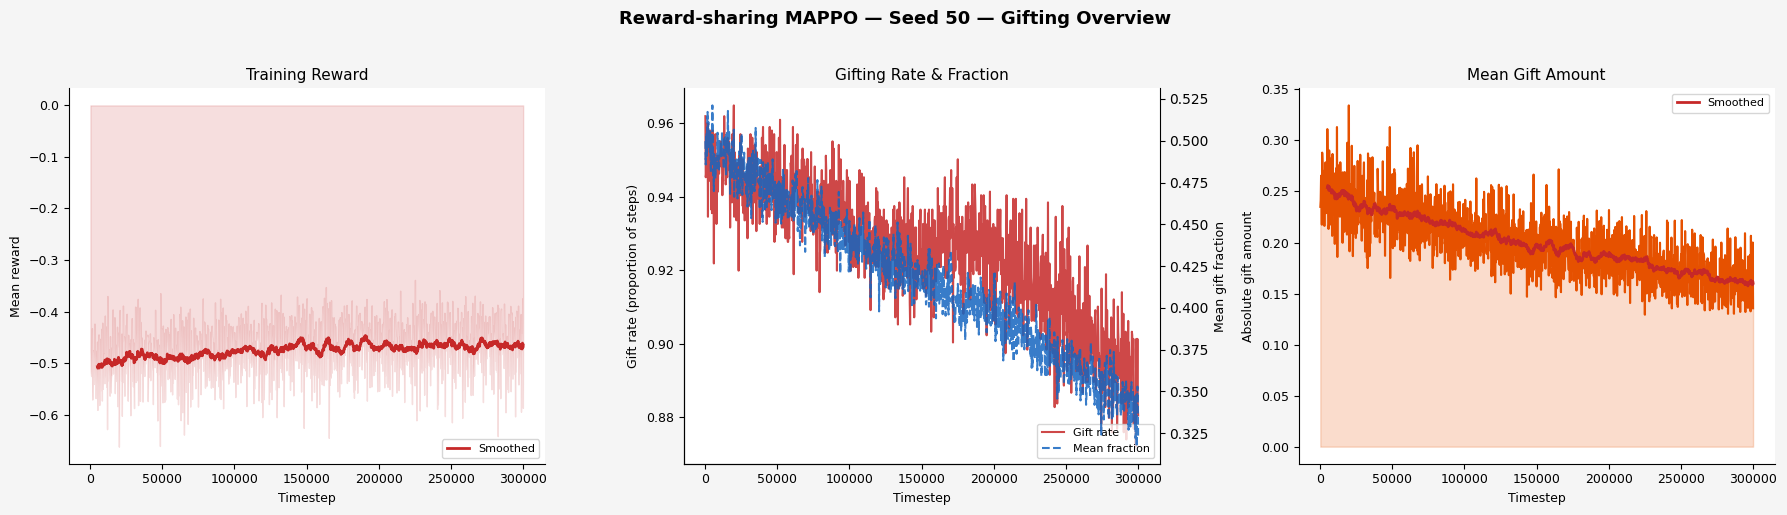

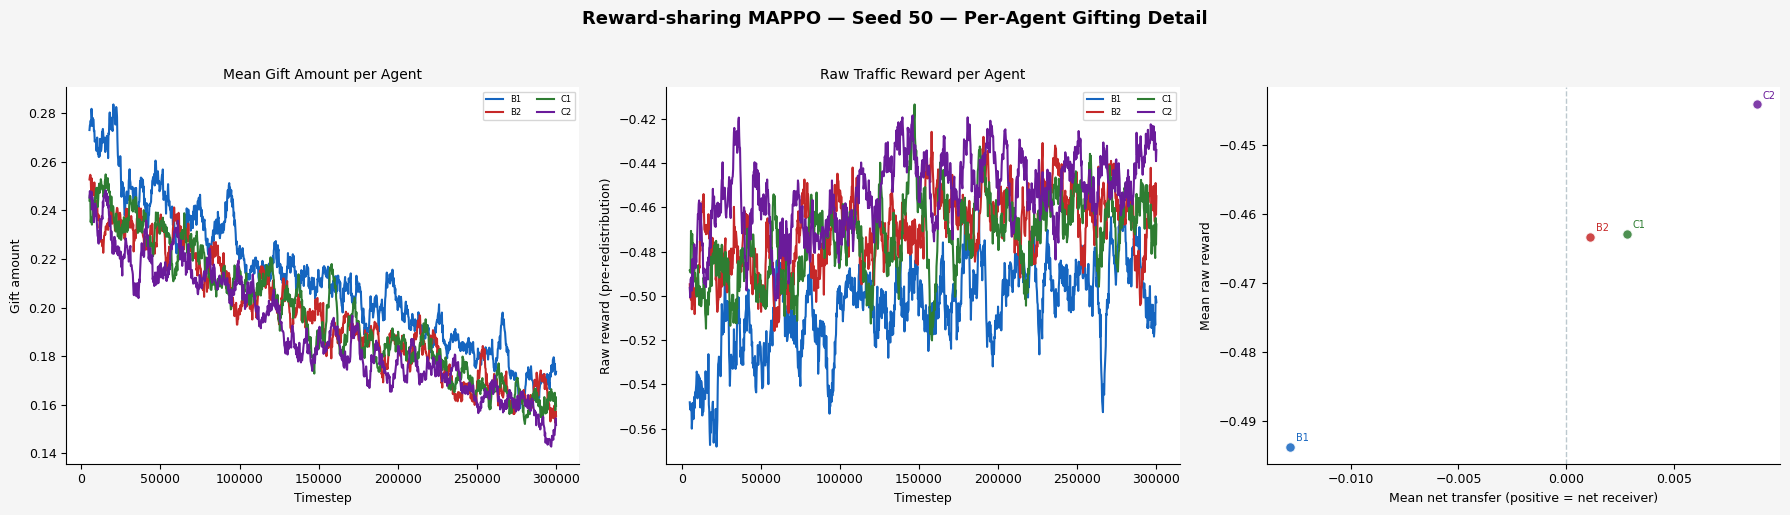


GIFTING SUMMARY — FULL TRAINING RUN

  B1
Giving:
    Mean gift fraction : 0.418
    Mean gift amount   : 0.2124
    Mean raw reward    : -0.5057
    Gift rate          : 0.926
Receiving and Net:    
    Mean received amount : 0.1953
    Mean net transfer    : -0.0171  (net donor)

  B2
Giving:
    Mean gift fraction : 0.418
    Mean gift amount   : 0.1973
    Mean raw reward    : -0.4696
    Gift rate          : 0.926
Receiving and Net:    
    Mean received amount : 0.2003
    Mean net transfer    : 0.0030  (net receiver)

  C1
Giving:
    Mean gift fraction : 0.417
    Mean gift amount   : 0.1979
    Mean raw reward    : -0.4730
    Gift rate          : 0.926
Receiving and Net:    
    Mean received amount : 0.2001
    Mean net transfer    : 0.0022  (net receiver)

  C2
Giving:
    Mean gift fraction : 0.418
    Mean gift amount   : 0.1906
    Mean raw reward    : -0.4536
    Gift rate          : 0.927
Receiving and Net:    
    Mean received amount : 0.2025
    Mean net transfer  

In [83]:
from marl_tsc.evaluate_gifting import gifting_visualisation, print_gifting_summary
for seed, history in enumerate(histories_rs):
    _seed = 42 + seed
    print(f"\n{'='*50}\nSeed {_seed}\n{'='*50}")
    gifting_visualisation(
        history=history,
        agent_ids=traffic_light_ids,
        algorithm_name=f"Reward-sharing MAPPO — Seed {_seed}",
        output_dir=str(OUTPUT_DIR),
        show=True,   # don't display inline for every seed
        save=False,    # just save to Drive
    )
    print_gifting_summary(history, traffic_light_ids)

In [84]:
!git status
#!git add .
commit = False
if commit:
  import shlex
  commit_msg = '''
  Updated to reflect gifts recieved as well as given
  '''
  !git config --global user.email user_email
  !git config --global user.name 'IsaacFayle-Waters'
  !git commit -m {shlex.quote(commit_msg)}

On branch zak-pre-experiment
Your branch is up to date with 'origin/zak-pre-experiment'.

nothing to commit, working tree clean


In [ ]:
#!git pull --rebase origin zak-pre-experiment

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 4 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 721.28 KiB | 1.70 MiB/s, done.
From https://github.com/abergh18/marl-tsc
 * branch            zak-pre-experiment -> FETCH_HEAD
   62a616d..e107429  zak-pre-experiment -> origin/zak-pre-experiment
Successfully rebased and updated refs/heads/zak-pre-experiment.


In [ ]:
#!git remote set-url origin https://{token}@github.com/abergh18/marl-tsc.git
#!git push -u origin zak-pre-experiment

Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (7/7), 1.22 KiB | 1.22 MiB/s, done.
Total 7 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), completed with 5 local objects.
To https://github.com/abergh18/marl-tsc.git
   e107429..1829ab2  zak-pre-experiment -> zak-pre-experiment
Branch 'zak-pre-experiment' set up to track remote branch 'zak-pre-experiment' from 'origin'.


# Learning Rate Tests (Ignore)

lr: 0.0003
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -300.09 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -319.29 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -314.31 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -302.38 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -312.38 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -295.65 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -301.56 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -295.90 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -314.84 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -296.17 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -283.24 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -275.43 | Total Steps: 7200
 Retrying in 1 s

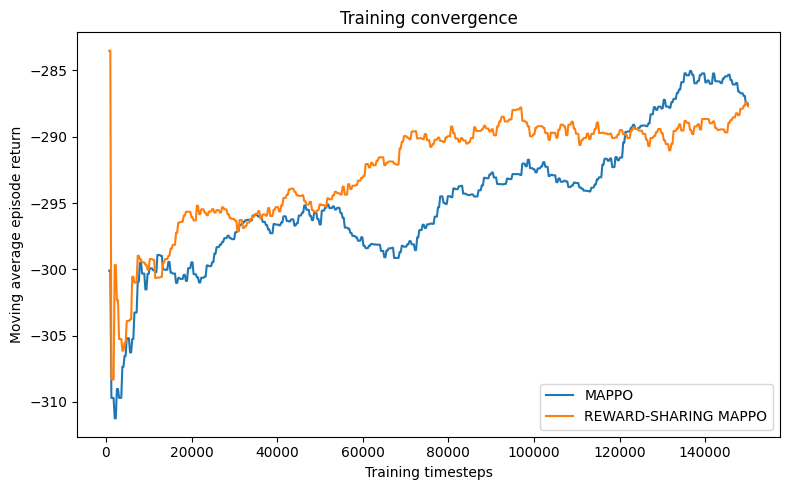

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1131.81
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1239.28
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1264.03
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -988.47
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -987.34
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -982.47
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -502.81
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -531.25
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -518.69
Evaluating Reward-shar

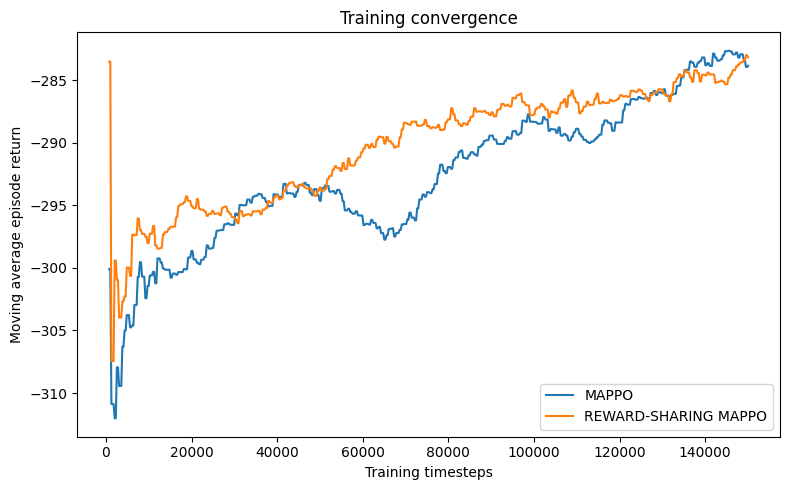

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1131.81
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1239.28
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1264.03
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -988.47
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -987.34
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -982.47
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -636.91
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -622.12
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -630.41
Evaluating Reward-shar

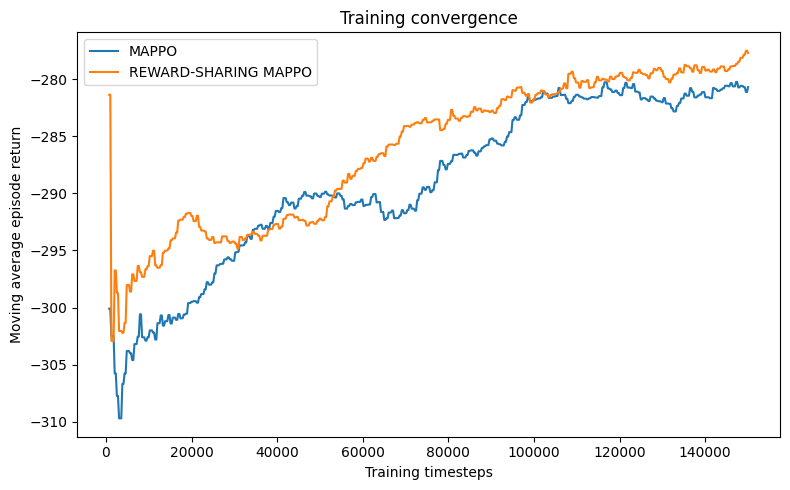

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1131.81
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1239.28
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1264.03
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -988.47
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -987.34
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -982.47
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -449.41
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -421.69
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -421.59
Evaluating Reward-shar

In [5]:
TOTAL_TIMESTEPS = 150_000
seed = SEED
#select network for seeded evaluation
network = GridNetwork(4)
generator = SimulationGenerator(
  output_dir=SIMULATION_DIR,
  network=network,
  trip_begin=0,
  trip_end=TRAFFIC_SPAWN_DURATION,
  trip_period=3,
  seed=SEED,
)

paths = generator.generate_all()
traffic_light_ids = list(paths.traffic_light_ids)

for lr in [3e-4, 5e-4, 1e-3]:
    print(f"lr: {lr}")
    #Run MAPPO
    mappo_model, mappo_history, mappo_path = train_mappo(
        config_file=paths.config_file,
        traffic_light_ids=traffic_light_ids,
        output_dir=OUTPUT_DIR,
        total_timesteps=TOTAL_TIMESTEPS,
        rollout_steps=256,
        max_steps=EPISODE_STEPS,
        lr=lr,
        seed=seed,
        env_kwargs=ENV_KWARGS,
        use_peer_reward=False,
    )

    #Run reward sharing
    reward_sharing_model, reward_sharing_history, reward_sharing_path = train_mappo(
        config_file=paths.config_file,
        traffic_light_ids=traffic_light_ids,
        output_dir=OUTPUT_DIR,
        total_timesteps=TOTAL_TIMESTEPS,
        rollout_steps=256,
        max_steps=EPISODE_STEPS,
        lr=lr,
        seed=seed,
        env_kwargs=ENV_KWARGS,
        use_peer_reward=True,
    )

    #Display
    fig, ax = plot_training_histories({
    "MAPPO": mappo_history,
    "Reward-sharing MAPPO": reward_sharing_history,
    })
    plt.show()

    #Evaluate
    policies = {
    "Random": random_actions,
    "Fixed-Time": fixed_time_actions,
    "MAPPO": mappo_model,
    "Reward-sharing MAPPO": reward_sharing_model,
    }

    policy_results = evaluate_policies(
        config_file=paths.config_file,
        traffic_light_ids=traffic_light_ids,
        policies=policies,
        episodes=EVALUATION_EPISODES,
        max_steps=EPISODE_STEPS,
        seed=SEED,
        env_kwargs=ENV_KWARGS,
    )
